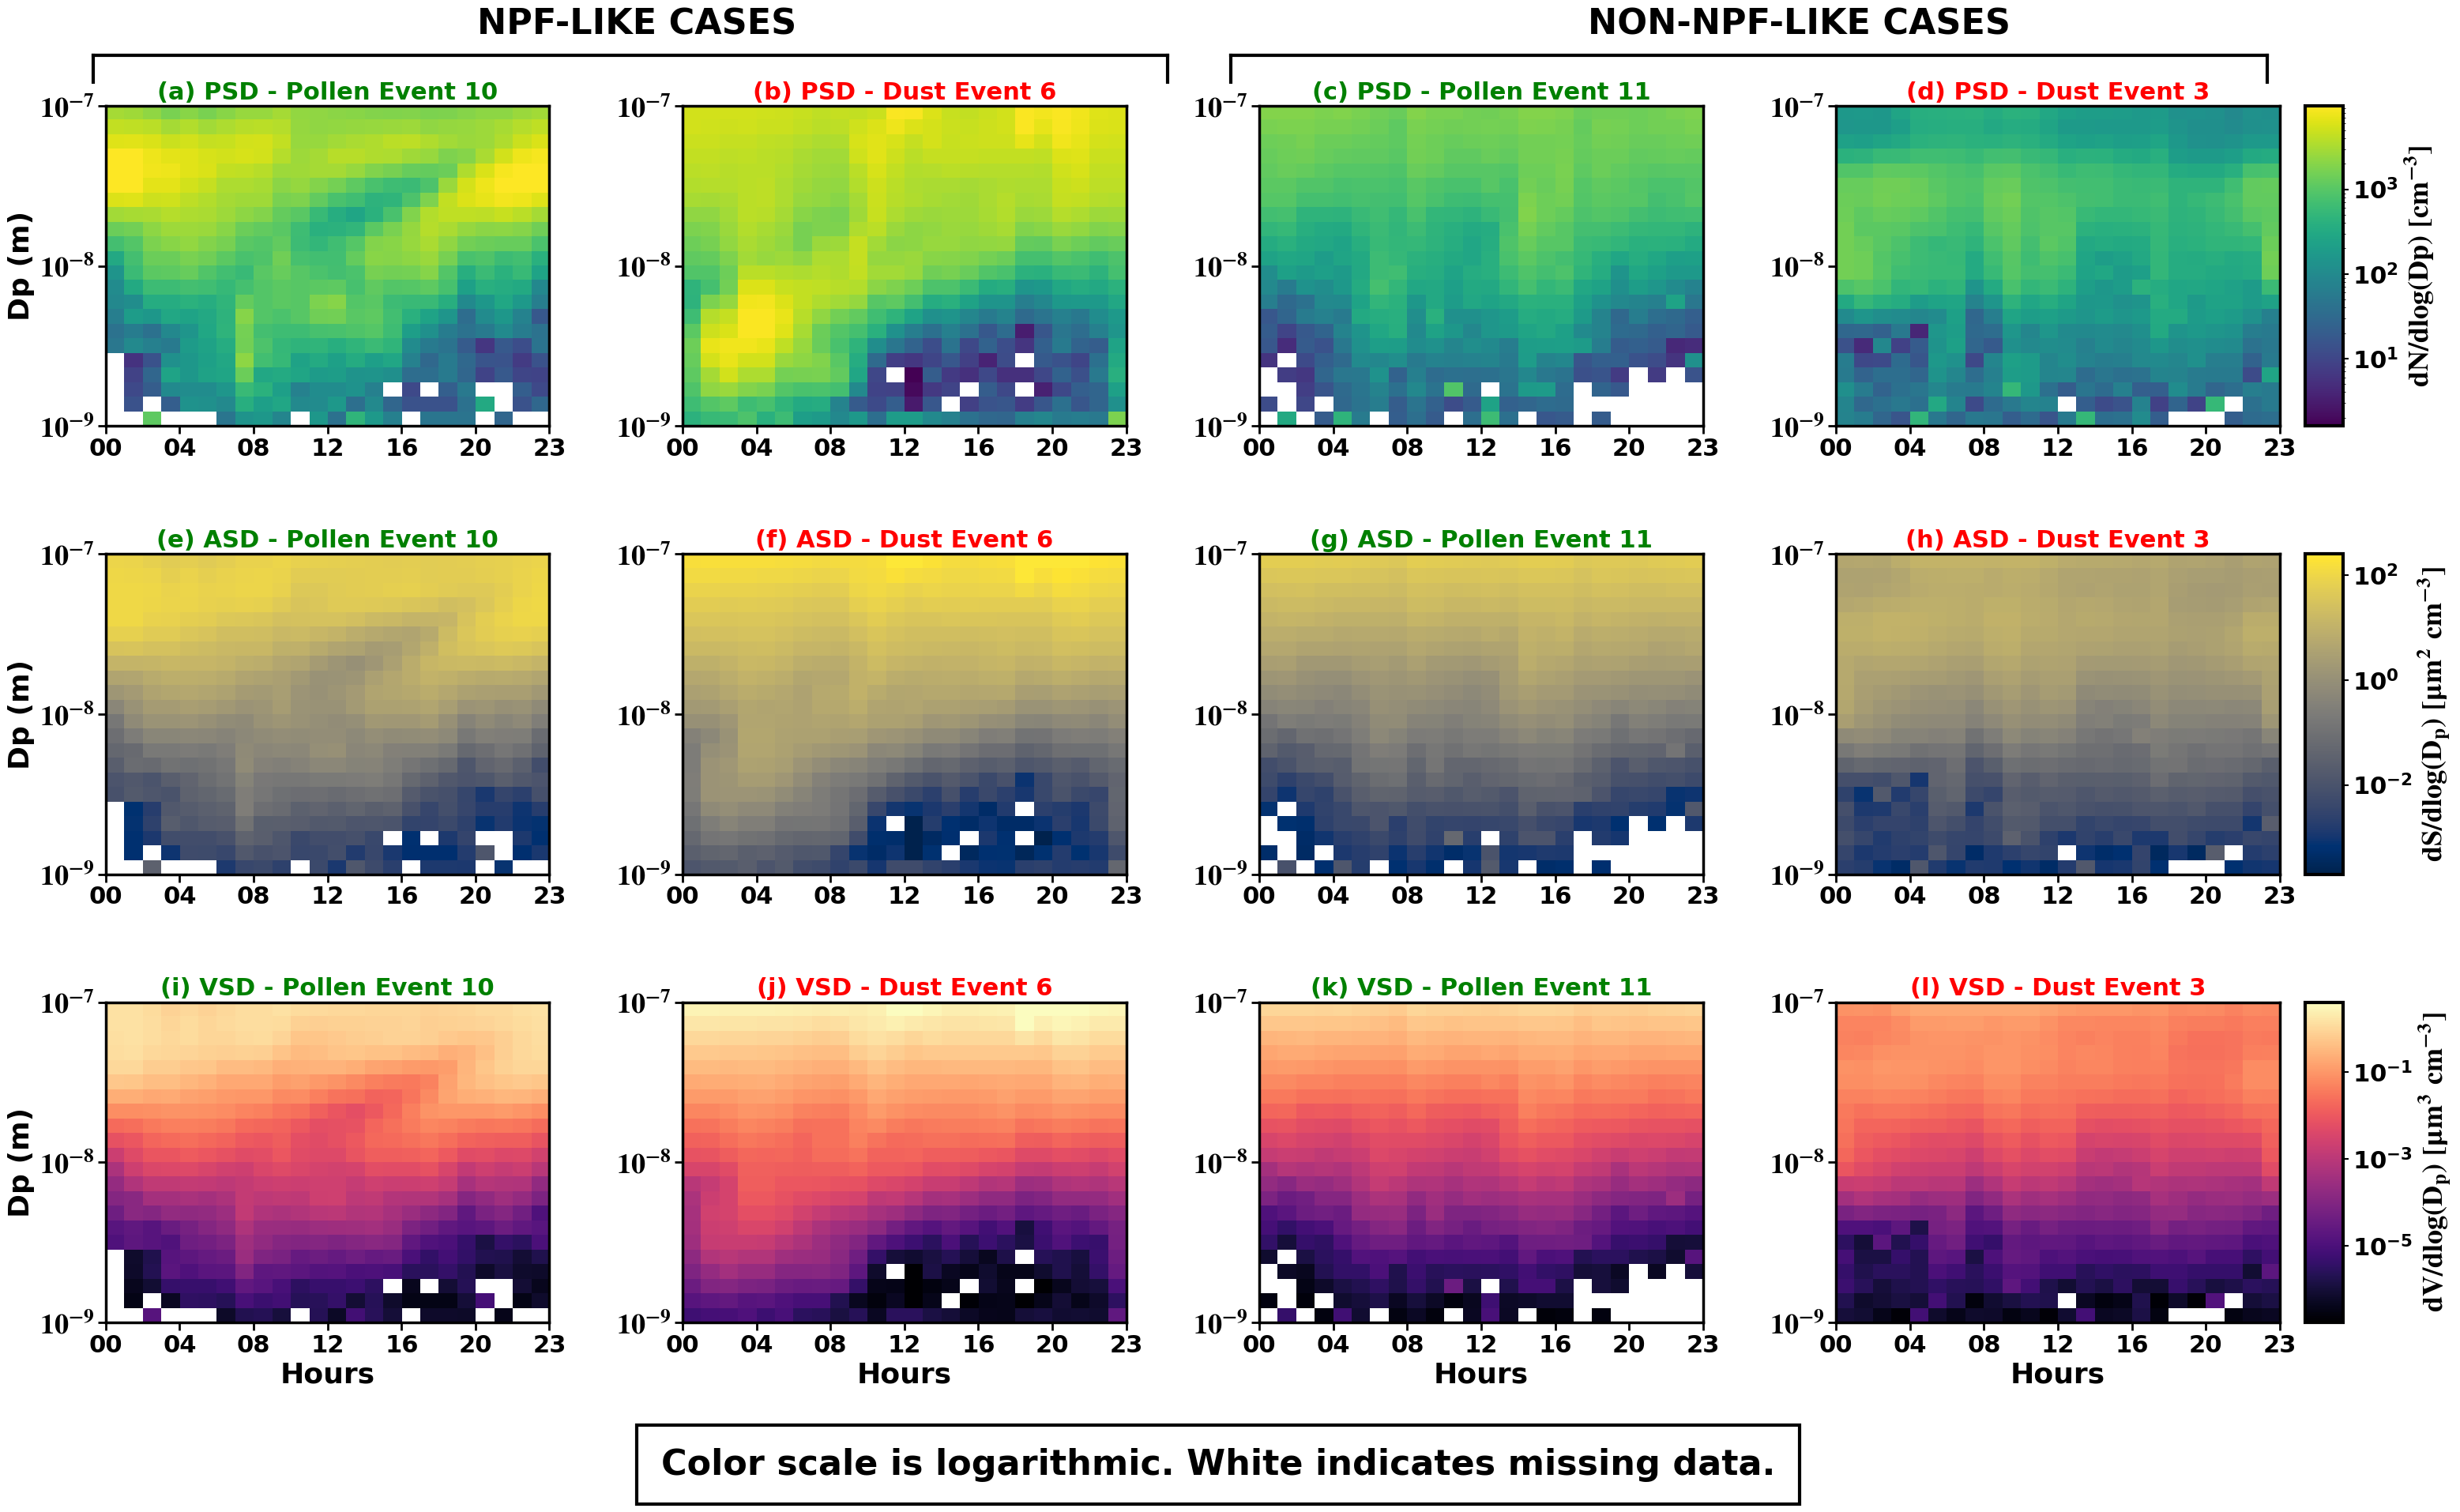


✅ Figure saved at: /Users/touqeergill/Desktop/Combined_NPF_NONNPF_12Plots.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext

# ============================================================
# === FORCE BOLD MATHTEXT ====================================
# ============================================================
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.weight'] = 'bold'

# ============================================================
# === FOLDERS ================================================
# ============================================================
pollen_folder = '/Users/touqeergill/Desktop/DMPS_APS_Pollen_Days'
dust_folder   = '/Users/touqeergill/Desktop/DMPS_APS_Dust_Days'

# ============================================================
# === NATURAL SORTING ========================================
# ============================================================
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split(r'(\d+)', s)]

# ============================================================
# === GET FILE LISTS =========================================
# ============================================================
pollen_files = sorted(
    [f for f in os.listdir(pollen_folder) if f.endswith('.xlsx')],
    key=natural_sort_key
)

dust_files = sorted(
    [f for f in os.listdir(dust_folder) if f.endswith('.xlsx')],
    key=natural_sort_key
)

# ============================================================
# === EVENT SELECTION ========================================
# ============================================================

# ---------------- NPF EVENTS ----------------
npf_pollen_file = pollen_files[9]   # Event 10
npf_dust_file   = dust_files[5]     # Event 6

# -------------- NON-NPF EVENTS --------------
nonnpf_pollen_file = pollen_files[10]   # Event 11
nonnpf_dust_file   = dust_files[2]      # Event 3

# ============================================================
# === GENERIC PROCESS FUNCTION ===============================
# ============================================================
def process_event(file_path, mode='number'):

    df = pd.read_excel(
        file_path,
        index_col='datetime',
        parse_dates=True
    )

    # ========================================================
    # === KEEP ONLY Dp < 100 nm ==============================
    # ========================================================
    valid_cols = []

    for c in df.columns:
        try:
            if float(c) < 1e-7:
                valid_cols.append(c)
        except:
            continue

    df = df[valid_cols]

    if df.empty:
        raise ValueError(f"No bins <100 nm in {file_path}")

    # ========================================================
    # === Dp ================================================
    # ========================================================
    Dp_m = df.columns.astype(float)
    Dp_um = Dp_m * 1e6

    # ========================================================
    # === CONVERSIONS ========================================
    # ========================================================
    if mode == 'asd':
        factor = np.pi * (Dp_um ** 2)
        df = df.multiply(factor, axis=1)

    elif mode == 'vsd':
        factor = (np.pi / 6) * (Dp_um ** 3)
        df = df.multiply(factor, axis=1)

    # ========================================================
    # === DIURNAL MEAN =======================================
    # ========================================================
    df_hourly = df.resample("H").mean()

    diurnal = (
        df_hourly
        .groupby(df_hourly.index.time)
        .mean()
    )

    min_positive = df[df > 0].min().min()

    diurnal = diurnal.fillna(min_positive)

    upper_99 = np.nanpercentile(diurnal.values, 99)

    diurnal = diurnal.clip(
        upper=min(upper_99, diurnal.values.max())
    )

    # ========================================================
    # === FIX TIME AXIS ======================================
    # ========================================================
    time_axis = pd.date_range(
        "00:00",
        "23:00",
        freq="H"
    ).time

    diurnal = diurnal.reindex(time_axis).fillna(min_positive)

    # ========================================================
    # === LOG AXIS ===========================================
    # ========================================================
    min_log = np.floor(np.log10(Dp_m.min()))
    max_log = np.ceil(np.log10(Dp_m.max()))

    ticks = np.logspace(
        min_log,
        max_log,
        int(max_log - min_log) + 1
    )

    return (
        diurnal,
        min_positive,
        upper_99,
        ticks,
        min_log,
        max_log
    )

# ============================================================
# === PROCESS ALL DATA =======================================
# ============================================================
datasets = {

    # ================= NPF =================
    "NPF_Number_Pollen": process_event(
        os.path.join(pollen_folder, npf_pollen_file),
        mode='number'
    ),

    "NPF_Number_Dust": process_event(
        os.path.join(dust_folder, npf_dust_file),
        mode='number'
    ),

    "NPF_ASD_Pollen": process_event(
        os.path.join(pollen_folder, npf_pollen_file),
        mode='asd'
    ),

    "NPF_ASD_Dust": process_event(
        os.path.join(dust_folder, npf_dust_file),
        mode='asd'
    ),

    "NPF_VSD_Pollen": process_event(
        os.path.join(pollen_folder, npf_pollen_file),
        mode='vsd'
    ),

    "NPF_VSD_Dust": process_event(
        os.path.join(dust_folder, npf_dust_file),
        mode='vsd'
    ),

    # ============== NON-NPF ================
    "NON_Number_Pollen": process_event(
        os.path.join(pollen_folder, nonnpf_pollen_file),
        mode='number'
    ),

    "NON_Number_Dust": process_event(
        os.path.join(dust_folder, nonnpf_dust_file),
        mode='number'
    ),

    "NON_ASD_Pollen": process_event(
        os.path.join(pollen_folder, nonnpf_pollen_file),
        mode='asd'
    ),

    "NON_ASD_Dust": process_event(
        os.path.join(dust_folder, nonnpf_dust_file),
        mode='asd'
    ),

    "NON_VSD_Pollen": process_event(
        os.path.join(pollen_folder, nonnpf_pollen_file),
        mode='vsd'
    ),

    "NON_VSD_Dust": process_event(
        os.path.join(dust_folder, nonnpf_dust_file),
        mode='vsd'
    )
}

# ============================================================
# === GLOBAL COLOR SCALES ====================================
# ============================================================
number_vmin = max(
    min(
        datasets["NPF_Number_Pollen"][1],
        datasets["NPF_Number_Dust"][1],
        datasets["NON_Number_Pollen"][1],
        datasets["NON_Number_Dust"][1]
    ),
    1
)

number_vmax = max(
    datasets["NPF_Number_Pollen"][2],
    datasets["NPF_Number_Dust"][2],
    datasets["NON_Number_Pollen"][2],
    datasets["NON_Number_Dust"][2]
)

asd_vmin = max(
    min(
        datasets["NPF_ASD_Pollen"][1],
        datasets["NPF_ASD_Dust"][1],
        datasets["NON_ASD_Pollen"][1],
        datasets["NON_ASD_Dust"][1]
    ),
    1e-9
)

asd_vmax = max(
    datasets["NPF_ASD_Pollen"][2],
    datasets["NPF_ASD_Dust"][2],
    datasets["NON_ASD_Pollen"][2],
    datasets["NON_ASD_Dust"][2]
)

vsd_vmin = max(
    min(
        datasets["NPF_VSD_Pollen"][1],
        datasets["NPF_VSD_Dust"][1],
        datasets["NON_VSD_Pollen"][1],
        datasets["NON_VSD_Dust"][1]
    ),
    1e-9
)

vsd_vmax = max(
    datasets["NPF_VSD_Pollen"][2],
    datasets["NPF_VSD_Dust"][2],
    datasets["NON_VSD_Pollen"][2],
    datasets["NON_VSD_Dust"][2]
)

# ============================================================
# === FIGURE SETUP ===========================================
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(32, 20))

# ============================================================
# === PLOT FUNCTION ==========================================
# ============================================================
def make_plot(ax,
              data,
              vmin,
              vmax,
              title,
              cmap_style='viridis'):
    
    diurnal = data[0]
    ticks = data[3]
    min_log = data[4]
    max_log = data[5]

    extent = [
        0,
        len(diurnal),
        min_log,
        max_log
    ]

    im = ax.imshow(
        diurnal.values.T,
        aspect='auto',
        interpolation='none',
        cmap=cmap_style,
        origin='lower',
        extent=extent,
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )

    # ========================================================
    # === TITLE ==============================================
    # ========================================================
    title_color = 'green' if 'Pollen' in title else 'red'
    ax.set_title(
        title,
        fontsize=22,
        fontweight='bold',
        color=title_color
)

    # ========================================================
    # === Y AXIS =============================================
    # ========================================================
    ax.set_yticks(np.log10(ticks))

    ax.set_yticklabels(
        [
            rf"$\mathbf{{10^{{{int(np.log10(t))}}}}}$"
            for t in ticks
        ],
        fontsize=26
    )

    for tick in ax.get_yticklabels():
        tick.set_fontsize(26)
        tick.set_fontweight('bold')
        
    # Show Dp only on first column
    if ax in [axes[0,0], axes[1,0], axes[2,0]]:
        ax.set_ylabel(
            "Dp (m)",
            fontsize=26,
            fontweight='bold'
        )
    else:
        ax.set_ylabel("")
        
    ax.tick_params(
        axis='y',
        labelsize=26,
        width=2,
        length=7
    )

    # ========================================================
    # === X AXIS =============================================
    # ========================================================
    ax.set_xticks(np.linspace(0, len(diurnal), 7))

    ax.set_xticklabels(
        ['00','04','08','12','16','20','23'],
        fontsize=22,
        fontweight='bold'
    )
        
    # Show Hours only on VSD row
    if ax in [axes[2,0], axes[2,1], axes[2,2], axes[2,3]]:
        ax.set_xlabel(
        "Hours",
        fontsize=26,
        fontweight='bold'
            
        )
    
    else:    
        ax.set_xlabel("")
        
    ax.tick_params(
        axis='both',
        which='both',
        width=2,
        length=7
    )
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    return im

# ============================================================
# === ROW 1 : PSD ============================================
# ============================================================
im1 = make_plot(
    axes[0,0],
    datasets["NPF_Number_Pollen"],
    number_vmin,
    number_vmax,
    "(a) PSD - Pollen Event 10",
    cmap_style='viridis'
)

make_plot(
    axes[0,1],
    datasets["NPF_Number_Dust"],
    number_vmin,
    number_vmax,
    "(b) PSD - Dust Event 6",
    cmap_style='viridis'
)

make_plot(
    axes[0,2],
    datasets["NON_Number_Pollen"],
    number_vmin,
    number_vmax,
    "(c) PSD - Pollen Event 11",
    cmap_style='viridis'
)

make_plot(
    axes[0,3],
    datasets["NON_Number_Dust"],
    number_vmin,
    number_vmax,
    "(d) PSD - Dust Event 3",
    cmap_style='viridis'
)

# ============================================================
# === ROW 2 : ASD ============================================
# ============================================================
im2 = make_plot(
    axes[1,0],
    datasets["NPF_ASD_Pollen"],
    asd_vmin,
    asd_vmax,
    "(e) ASD - Pollen Event 10",
    cmap_style='cividis'
)

make_plot(
    axes[1,1],
    datasets["NPF_ASD_Dust"],
    asd_vmin,
    asd_vmax,
    "(f) ASD - Dust Event 6",
    cmap_style='cividis'
)

make_plot(
    axes[1,2],
    datasets["NON_ASD_Pollen"],
    asd_vmin,
    asd_vmax,
    "(g) ASD - Pollen Event 11",
    cmap_style='cividis'
)

make_plot(
    axes[1,3],
    datasets["NON_ASD_Dust"],
    asd_vmin,
    asd_vmax,
    "(h) ASD - Dust Event 3",
    cmap_style='cividis'
)

# ============================================================
# === ROW 3 : VSD ============================================
# ============================================================
im3 = make_plot(
    axes[2,0],
    datasets["NPF_VSD_Pollen"],
    vsd_vmin,
    vsd_vmax,
    "(i) VSD - Pollen Event 10",
    cmap_style='magma'
)

make_plot(
    axes[2,1],
    datasets["NPF_VSD_Dust"],
    vsd_vmin,
    vsd_vmax,
    "(j) VSD - Dust Event 6",
    cmap_style='magma'
)

make_plot(
    axes[2,2],
    datasets["NON_VSD_Pollen"],
    vsd_vmin,
    vsd_vmax,
    "(k) VSD - Pollen Event 11",
    cmap_style='magma'
)

make_plot(
    axes[2,3],
    datasets["NON_VSD_Dust"],
    vsd_vmin,
    vsd_vmax,
    "(l) VSD - Dust Event 3",
    cmap_style='magma'
)

# ============================================================
# === GROUP TITLES ===========================================
# ============================================================

# NPF title
fig.text(
    0.27,
    0.985,
    'NPF-LIKE CASES',
    fontsize=32,
    fontweight='bold',
    ha='center'
)

# NON-NPF title
fig.text(
    0.73,
    0.985,
    'NON-NPF-LIKE CASES',
    fontsize=32,
    fontweight='bold',
    ha='center'
)

# ============================================================
# === BRACKETS ABOVE PANELS ==================================
# ============================================================

# NPF bracket
fig.lines.extend([
    plt.Line2D([0.055, 0.48], [0.972, 0.972],
               transform=fig.transFigure,
               color='black', linewidth=3),

    plt.Line2D([0.055, 0.055], [0.972, 0.955],
               transform=fig.transFigure,
               color='black', linewidth=3),

    plt.Line2D([0.48, 0.48], [0.972, 0.955],
               transform=fig.transFigure,
               color='black', linewidth=3)
])

# NON-NPF bracket
fig.lines.extend([
    plt.Line2D([0.505, 0.915], [0.972, 0.972],
               transform=fig.transFigure,
               color='black', linewidth=3),

    plt.Line2D([0.505, 0.505], [0.972, 0.955],
               transform=fig.transFigure,
               color='black', linewidth=3),

    plt.Line2D([0.915, 0.915], [0.972, 0.955],
               transform=fig.transFigure,
               color='black', linewidth=3)
])

# ============================================================
# === SUBPLOT SPACING ========================================
# ============================================================
fig.subplots_adjust(
    left=0.06,
    right=0.92,
    top=0.94,
    bottom=0.17,
    hspace=0.40,
    wspace=0.30
)

# ============================================================
# === COLORBAR 1 : PSD =======================================
# ============================================================
# PSD colorbar
pos = axes[0,3].get_position()
cbar_ax1 = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])

cbar1 = fig.colorbar(im1, cax=cbar_ax1)
cbar1.outline.set_linewidth(3)
cbar1.formatter = LogFormatterMathtext()
cbar1.update_ticks()

cbar1.ax.tick_params(
    labelsize=22,
    width=1.5,
    length=5
)

for tick in cbar1.ax.get_yticklabels():
    tick.set_fontweight('bold')

cbar1.set_label(
    '$\\mathbf{dN/dlog(Dp)\\ [cm^{-3}]}$',
    fontsize=26,
    fontweight='bold'
)

# ============================================================
# === COLORBAR 2 : ASD =======================================
# ============================================================
# ASD colorbar
pos = axes[1,3].get_position()
cbar_ax2 = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])

cbar2 = fig.colorbar(im2, cax=cbar_ax2)
cbar2.outline.set_linewidth(3)
cbar2.formatter = LogFormatterMathtext()
cbar2.update_ticks()

cbar2.ax.tick_params(
    labelsize=22,
    width=1.5,
    length=5
)

for tick in cbar2.ax.get_yticklabels():
    tick.set_fontweight('bold')

cbar2.set_label(
    r"$\mathbf{dS/dlog(D_p)\ [\mu m^2\ cm^{-3}]}$",
    fontsize=26,
    fontweight='bold'
)

# ============================================================
# === COLORBAR 3 : VSD =======================================
# ============================================================
# VSD colorbar
pos = axes[2,3].get_position()
cbar_ax3 = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])

cbar3 = fig.colorbar(im3, cax=cbar_ax3)
cbar3.outline.set_linewidth(3)
cbar3.formatter = LogFormatterMathtext()
cbar3.update_ticks()

cbar3.ax.tick_params(
    labelsize=22,
    width=1.5,
    length=5
)

for tick in cbar3.ax.get_yticklabels():
    tick.set_fontweight('bold')

cbar3.set_label(
    r"$\mathbf{dV/dlog(D_p)\ [\mu m^3\ cm^{-3}]}$",
    fontsize=26,
    fontweight='bold'
)


# ============================================================
# === FOOTNOTE ===============================================
# ============================================================
from matplotlib.patches import Rectangle

# Draw rectangle
rect = Rectangle(
    (0.27, 0.055),   # x, y
    0.46,            # width
    0.05,            # height
    transform=fig.transFigure,
    facecolor='white',
    edgecolor='black',
    linewidth=3
)
fig.add_artist(rect)

# Text
fig.text(
    0.5,
    0.08,
    'Color scale is logarithmic. White indicates missing data.',
    ha='center',
    va='center',
    fontsize=32,
    fontweight='bold'
)

# ============================================================
# === SAVE ===================================================
# ============================================================
output_path = '/Users/touqeergill/Desktop/Combined_NPF_NONNPF_12Plots.png'

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.20
)

plt.show()

print(f"\n✅ Figure saved at: {output_path}")

Total pollen events found: 21
All pollen PSD events processed successfully.
Global minimum = 1.00
Global maximum = 14402.69


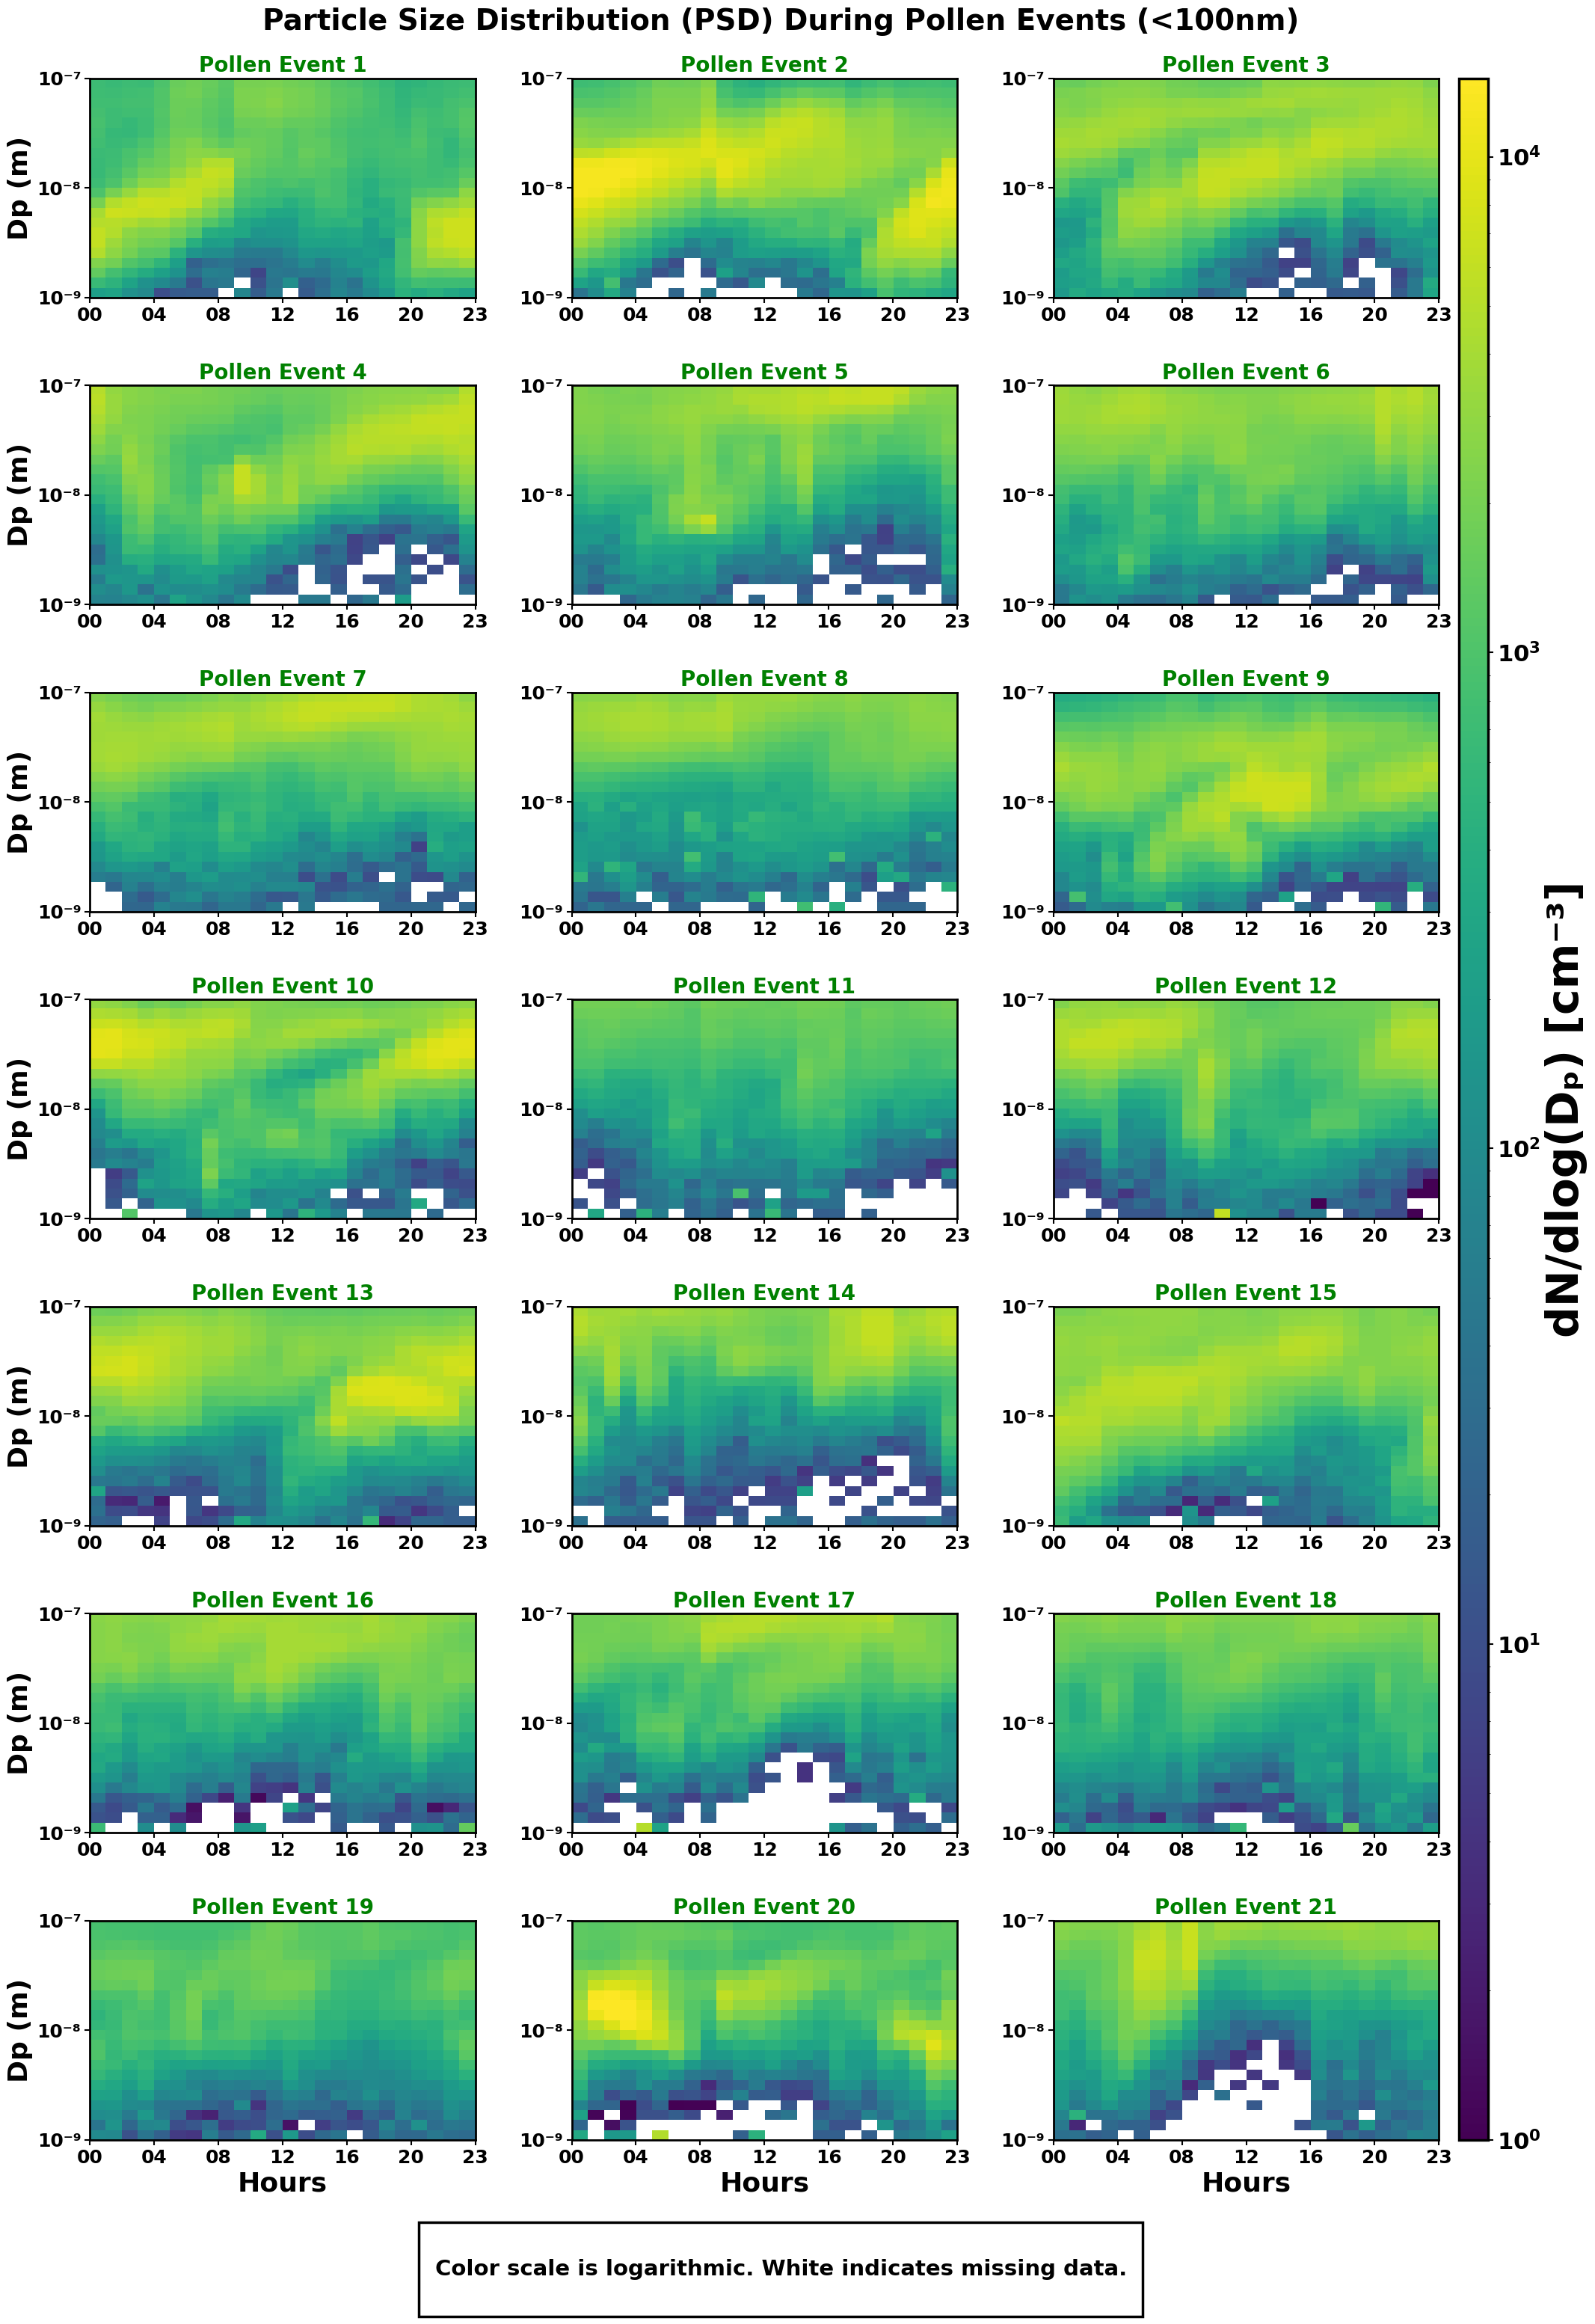


Figure saved successfully!
/Users/touqeergill/Desktop/PSD_All_Pollen_Events.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.patches import Rectangle

# ============================================================
# === FONT SETTINGS ==========================================
# ============================================================

plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.weight"] = "bold"

# ============================================================
# === FOLDER =================================================
# ============================================================

folder_path = "/Users/touqeergill/Desktop/DMPS_APS_Pollen_Days"

# ============================================================
# === NATURAL SORTING ========================================
# ============================================================

def natural_sort_key(s):

    return [

        int(text) if text.isdigit() else text.lower()

        for text in re.split(r'(\d+)', s)

    ]

# ============================================================
# === READ ALL EXCEL FILES ===================================
# ============================================================

excel_files = sorted(

    [

        f

        for f in os.listdir(folder_path)

        if f.endswith(".xlsx")

    ],

    key=natural_sort_key

)

print(f"Total pollen events found: {len(excel_files)}")

# ============================================================
# === PROCESS FUNCTION =======================================
# ============================================================

def process_event(file_path):

    df = pd.read_excel(

        file_path,

        index_col="datetime",

        parse_dates=True

    )

    # ========================================================
    # === KEEP ONLY Dp < 100 nm ==============================
    # ========================================================

    valid_cols = []

    for c in df.columns:

        try:

            if float(c) < 1e-7:

                valid_cols.append(c)

        except:

            continue

    df = df[valid_cols]

    if df.empty:

        raise ValueError(

            f"No bins below 100 nm in {file_path}"

        )

    # ========================================================
    # === PARTICLE DIAMETER ==================================
    # ========================================================

    Dp_m = df.columns.astype(float)

    # ========================================================
    # === HOURLY MEAN ========================================
    # ========================================================

    df_hourly = df.resample("H").mean()

    diurnal = (

        df_hourly

        .groupby(df_hourly.index.time)

        .mean()

    )

    # ========================================================
    # === MISSING VALUES =====================================
    # ========================================================

    min_positive = df[df > 0].min().min()

    diurnal = diurnal.fillna(min_positive)

    # ========================================================
    # === CLIP EXTREME VALUES ================================
    # ========================================================

    upper_99 = np.nanpercentile(

        diurnal.values,

        99

    )

    diurnal = diurnal.clip(

        upper=min(

            upper_99,

            diurnal.values.max()

        )

    )

    # ========================================================
    # === COMPLETE 24-HOUR AXIS ==============================
    # ========================================================

    time_axis = pd.date_range(

        "00:00",

        "23:00",

        freq="H"

    ).time

    diurnal = (

        diurnal

        .reindex(time_axis)

        .fillna(min_positive)

    )

    # ========================================================
    # === LOG TICKS ==========================================
    # ========================================================

    min_log = np.floor(np.log10(Dp_m.min()))

    max_log = np.ceil(np.log10(Dp_m.max()))

    ticks = np.logspace(

        min_log,

        max_log,

        int(max_log - min_log) + 1

    )

    return (

        diurnal,

        min_positive,

        upper_99,

        ticks,

        min_log,

        max_log

    )

# ============================================================
# === PROCESS ALL EVENTS =====================================
# ============================================================

datasets = {}

for file_name in excel_files:

    datasets[file_name] = process_event(

        os.path.join(

            folder_path,

            file_name

        )

    )

print("All pollen PSD events processed successfully.")

# ============================================================
# === GLOBAL COLOR SCALE =====================================
# ============================================================

number_vmin = max(

    min(

        datasets[file][1]

        for file in excel_files

    ),

    1

)

number_vmax = max(

    datasets[file][2]

    for file in excel_files

)

print(f"Global minimum = {number_vmin:.2f}")
print(f"Global maximum = {number_vmax:.2f}")

# ============================================================
# === FIGURE LAYOUT ==========================================
# ============================================================

n_files = len(excel_files)

n_cols = 3

n_rows = int(np.ceil(n_files / n_cols))

fig, axes = plt.subplots(

    n_rows,

    n_cols,

    figsize=(22, n_rows * 4.5)

)

axes = axes.flatten()

# ============================================================
# === PLOT FUNCTION ==========================================
# ============================================================

def make_plot(

    ax,

    data,

    title,

    vmin,

    vmax,

    cmap_style="viridis"

):

    diurnal = data[0]

    ticks = data[3]

    min_log = data[4]

    max_log = data[5]

    extent = [

        0,

        len(diurnal),

        min_log,

        max_log

    ]

    im = ax.imshow(

        diurnal.values.T,

        aspect="auto",

        interpolation="none",

        cmap=cmap_style,

        origin="lower",

        extent=extent,

        norm=LogNorm(

            vmin=vmin,

            vmax=vmax

        )

    )

    # ========================================================
    # === TITLE ==============================================
    # ========================================================

    ax.set_title(

        title,

        fontsize=20,

        fontweight="bold",

        color="green"

    )

    # ========================================================
    # === Y AXIS =============================================
    # ========================================================
    
    ax.set_yticks(np.log10(ticks))
    
    labels = [
        f"10{str(int(np.log10(t))).translate(str.maketrans('0123456789-', '⁰¹²³⁴⁵⁶⁷⁸⁹⁻'))}"
        for t in ticks
    ]
    
    ax.set_yticks(np.log10(ticks), labels=labels)
    
    for tick in ax.get_yticklabels():
        tick.set_fontsize(18)
        tick.set_fontweight("bold")
        
    # Only first column gets Y-axis label

    if (np.where(axes == ax)[0][0] % n_cols) == 0:

        ax.set_ylabel(

            "Dp (m)",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_ylabel("")

    ax.tick_params(

        axis="y",

        labelsize=18,

        width=1.5,

        length=5

    )

    # ========================================================
    # === X AXIS =============================================
    # ========================================================

    ax.set_xticks(

        np.linspace(

            0,

            len(diurnal),

            7

        )

    )

    ax.set_xticklabels(

        [

            "00",

            "04",

            "08",

            "12",

            "16",

            "20",

            "23"

        ],

        fontsize=18,

        fontweight="bold"

    )

    # Only last row gets X-axis label

    row_index = np.where(axes == ax)[0][0] // n_cols

    if row_index == n_rows - 1:

        ax.set_xlabel(

            "Hours",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_xlabel("")

    ax.tick_params(

        axis="both",

        which="both",

        width=1.5,

        length=5

    )

    for spine in ax.spines.values():

        spine.set_linewidth(2)

    return im

# ============================================================
# === PLOT ALL POLLEN EVENTS ================================
# ============================================================

letters = list("abcdefghijklmnopqrstuvwxyz")

for i, file_name in enumerate(excel_files):

    data = datasets[file_name]

    title = f"Pollen Event {i+1}"

    im = make_plot(
        axes[i],
        data,
        title,
        number_vmin,
        number_vmax,
        cmap_style="viridis"
    )

# ============================================================
# === REMOVE UNUSED AXES =====================================
# ============================================================

for j in range(len(excel_files), len(axes)):

    fig.delaxes(axes[j])

# ============================================================
# === MAIN TITLE =============================================
# ============================================================

fig.suptitle(

    "Particle Size Distribution (PSD) During Pollen Events (<100nm)",

    fontsize=28,

    fontweight="bold",

    y=0.995

)

# ============================================================
# === SUBPLOT SPACING ========================================
# ============================================================

fig.subplots_adjust(

    left=0.08,

    right=0.90,

    top=0.965,

    bottom=0.09,

    hspace=0.40,

    wspace=0.25

)

# ============================================================
# === MAKE ALL TICK LABELS BOLD ==============================
# ============================================================

for ax in axes[:len(excel_files)]:

    for tick in ax.get_xticklabels():

        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():

        tick.set_fontweight("bold")
        
# ============================================================
# === FULL HEIGHT COLORBAR ===================================
# ============================================================

# Top-right subplot
top_pos = axes[2].get_position()

# Bottom-right subplot
bottom_pos = axes[min(len(excel_files)-1, len(axes)-1)].get_position()

# Colorbar spans the full figure height
cbar_ax = fig.add_axes([

    top_pos.x1 + 0.012,

    bottom_pos.y0,

    0.018,

    top_pos.y1 - bottom_pos.y0

])

cbar = fig.colorbar(

    im,

    cax=cbar_ax

)

cbar.outline.set_linewidth(2.5)

cbar.formatter = LogFormatterMathtext()

cbar.update_ticks()

cbar.ax.tick_params(

    labelsize=22,

    width=1.5,

    length=5

)

for tick in cbar.ax.get_yticklabels():

    tick.set_fontweight("bold")

cbar.set_label(
    
    "dN/dlog(Dₚ) [cm⁻³]",
    
    fontsize=42,
    
    fontweight="bold"
)

# ============================================================
# === FOOTNOTE ===============================================
# ============================================================

rect = Rectangle(

    (

        0.28,

        0.015

    ),

    0.44,

    0.04,

    transform=fig.transFigure,

    facecolor="white",

    edgecolor="black",

    linewidth=2.5

)

fig.add_artist(rect)

fig.text(

    0.50,

    0.035,

    "Color scale is logarithmic. White indicates missing data.",

    ha="center",

    va="center",

    fontsize=21,

    fontweight="bold"

)

# ============================================================
# === SAVE FIGURE ============================================
# ============================================================

output_path = (

    "/Users/touqeergill/Desktop/PSD_All_Pollen_Events.png"

)

plt.savefig(

    output_path,

    dpi=300,

    bbox_inches="tight",

    pad_inches=0.20

)

plt.show()

print()

print("=" * 60)

print("Figure saved successfully!")

print(output_path)

print("=" * 60)

Total pollen events found: 15
All dust PSD events processed successfully.
Global minimum = 1.59
Global maximum = 9321.28


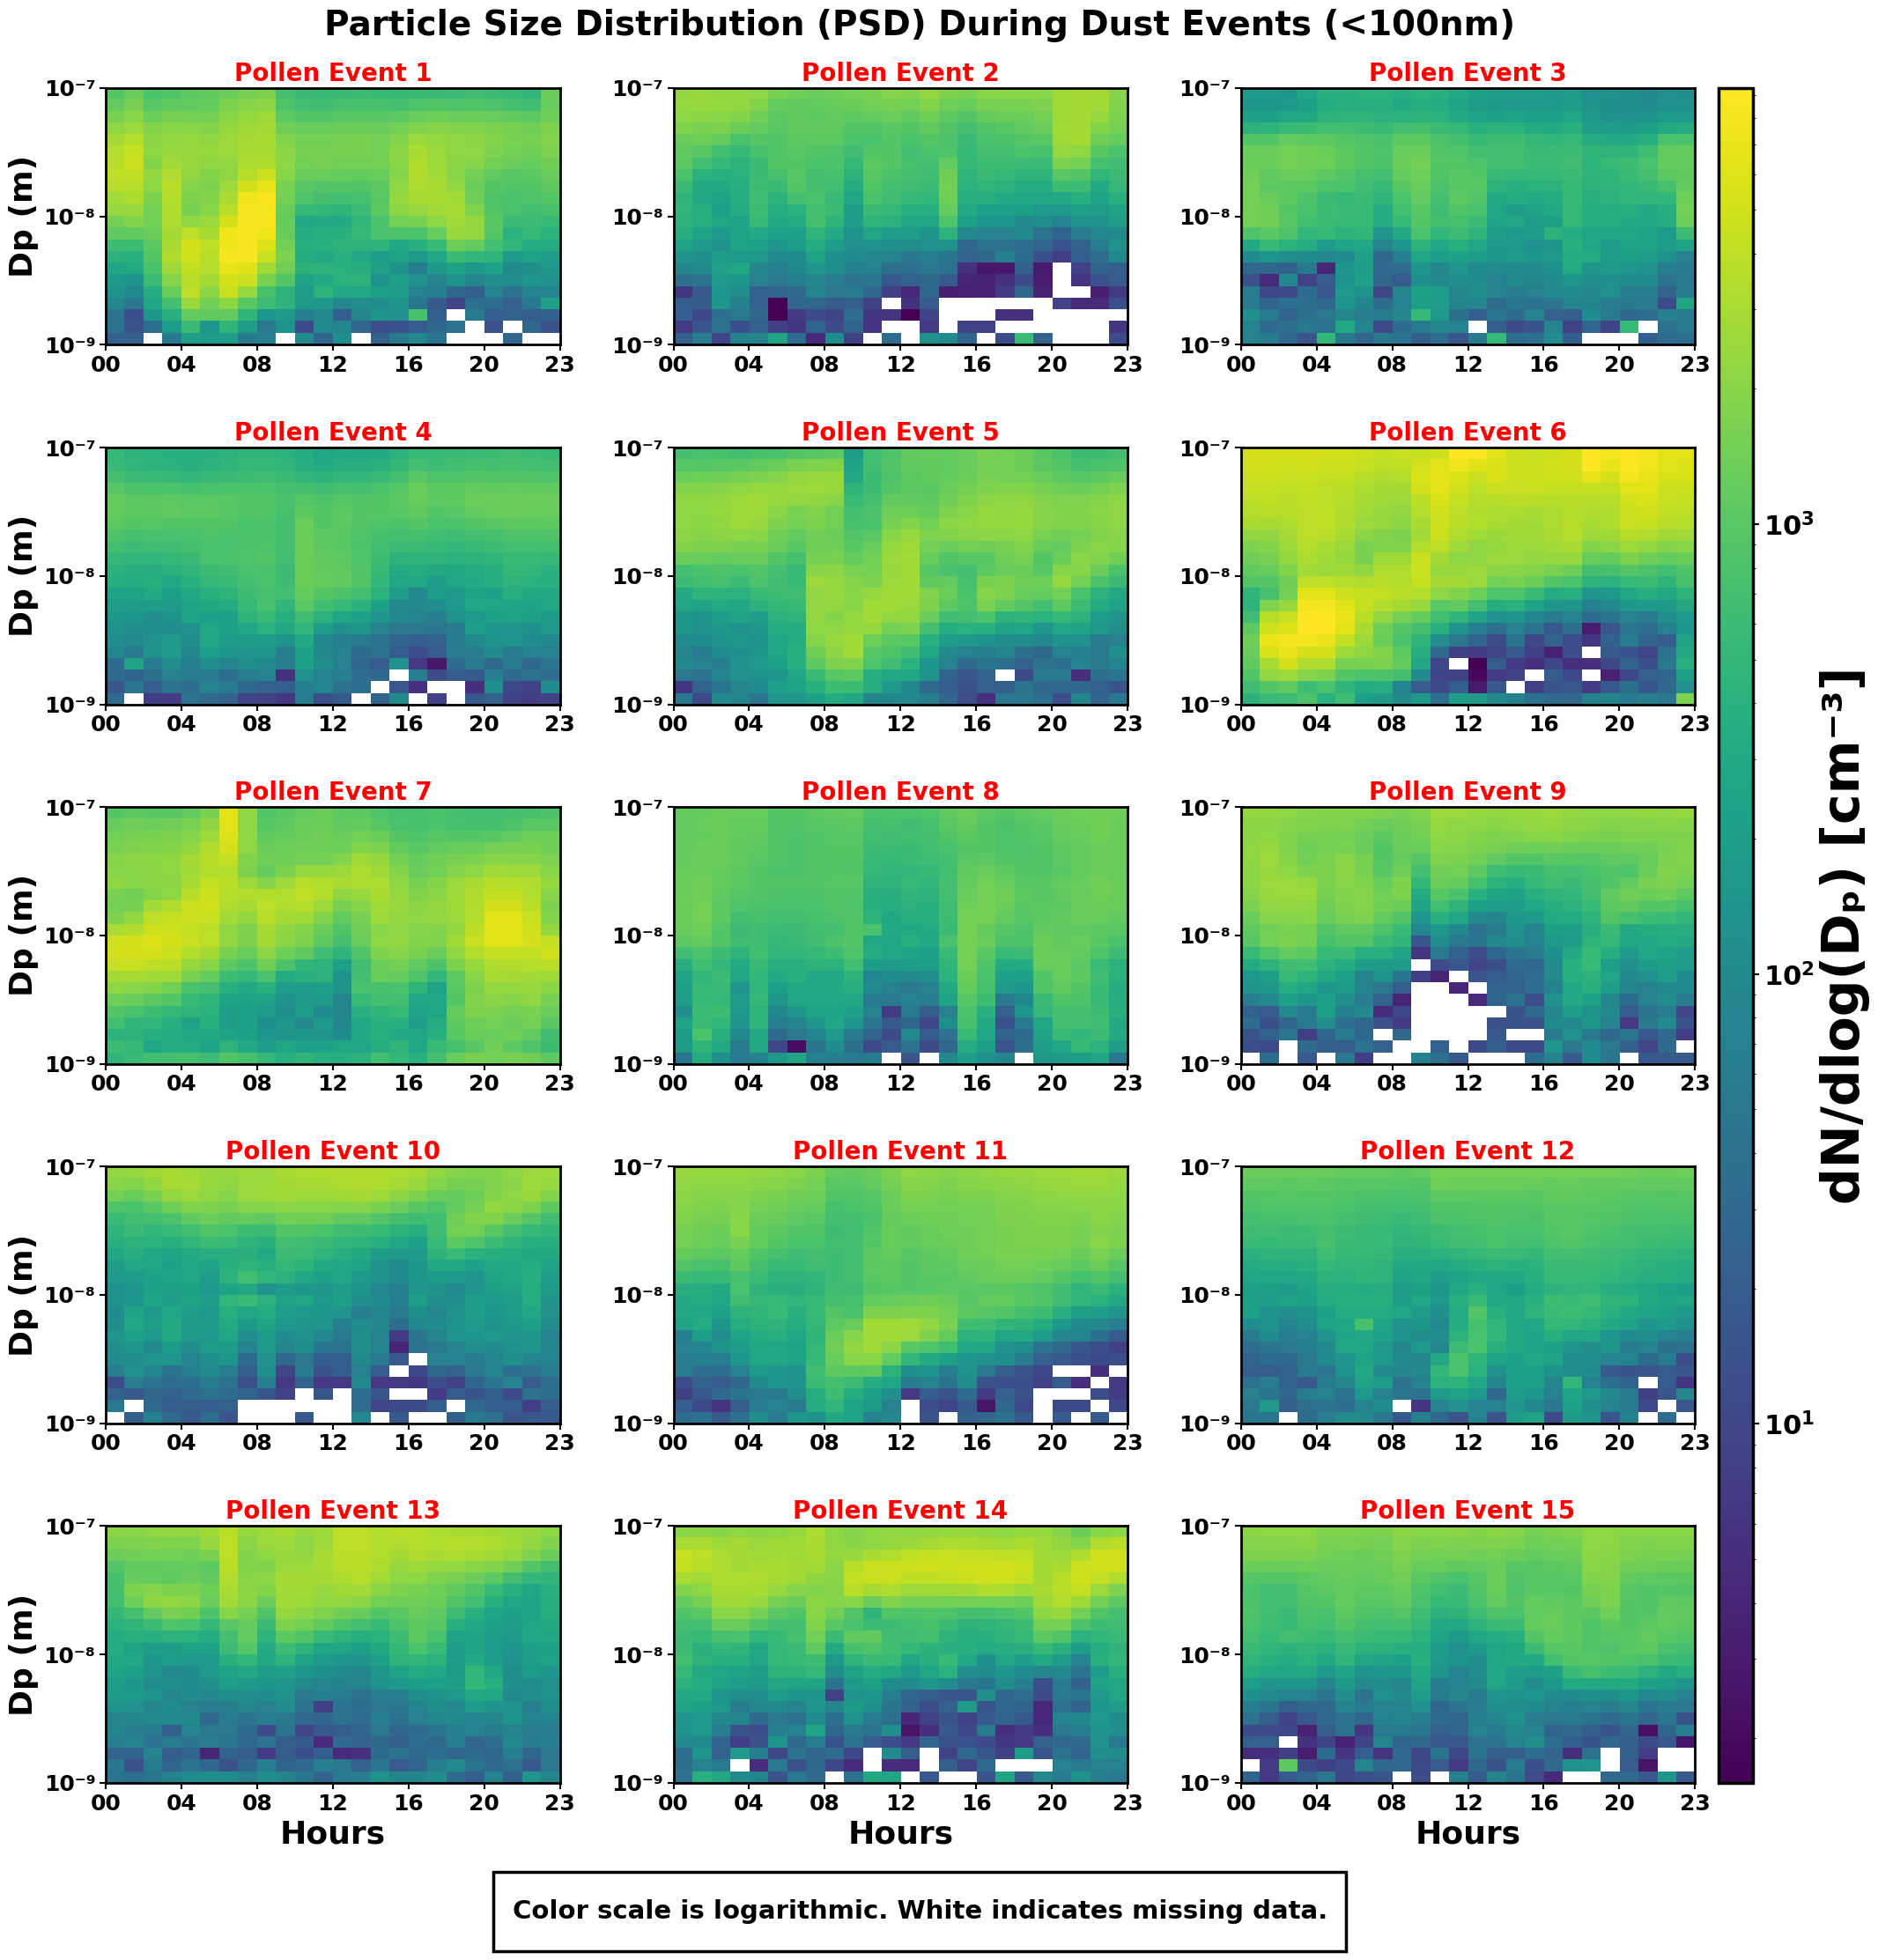


Figure saved successfully!
/Users/touqeergill/Desktop/PSD_All_Pollen_Events.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.patches import Rectangle

# ============================================================
# === FONT SETTINGS ==========================================
# ============================================================

plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.weight"] = "bold"

# ============================================================
# === FOLDER =================================================
# ============================================================

folder_path = "/Users/touqeergill/Desktop/DMPS_APS_Dust_Days"

# ============================================================
# === NATURAL SORTING ========================================
# ============================================================

def natural_sort_key(s):

    return [

        int(text) if text.isdigit() else text.lower()

        for text in re.split(r'(\d+)', s)

    ]

# ============================================================
# === READ ALL EXCEL FILES ===================================
# ============================================================

excel_files = sorted(

    [

        f

        for f in os.listdir(folder_path)

        if f.endswith(".xlsx")

    ],

    key=natural_sort_key

)

print(f"Total pollen events found: {len(excel_files)}")

# ============================================================
# === PROCESS FUNCTION =======================================
# ============================================================

def process_event(file_path):

    df = pd.read_excel(

        file_path,

        index_col="datetime",

        parse_dates=True

    )

    # ========================================================
    # === KEEP ONLY Dp < 100 nm ==============================
    # ========================================================

    valid_cols = []

    for c in df.columns:

        try:

            if float(c) < 1e-7:

                valid_cols.append(c)

        except:

            continue

    df = df[valid_cols]

    if df.empty:

        raise ValueError(

            f"No bins below 100 nm in {file_path}"

        )

    # ========================================================
    # === PARTICLE DIAMETER ==================================
    # ========================================================

    Dp_m = df.columns.astype(float)

    # ========================================================
    # === HOURLY MEAN ========================================
    # ========================================================

    df_hourly = df.resample("H").mean()

    diurnal = (

        df_hourly

        .groupby(df_hourly.index.time)

        .mean()

    )

    # ========================================================
    # === MISSING VALUES =====================================
    # ========================================================

    min_positive = df[df > 0].min().min()

    diurnal = diurnal.fillna(min_positive)

    # ========================================================
    # === CLIP EXTREME VALUES ================================
    # ========================================================

    upper_99 = np.nanpercentile(

        diurnal.values,

        99

    )

    diurnal = diurnal.clip(

        upper=min(

            upper_99,

            diurnal.values.max()

        )

    )

    # ========================================================
    # === COMPLETE 24-HOUR AXIS ==============================
    # ========================================================

    time_axis = pd.date_range(

        "00:00",

        "23:00",

        freq="H"

    ).time

    diurnal = (

        diurnal

        .reindex(time_axis)

        .fillna(min_positive)

    )

    # ========================================================
    # === LOG TICKS ==========================================
    # ========================================================

    min_log = np.floor(np.log10(Dp_m.min()))

    max_log = np.ceil(np.log10(Dp_m.max()))

    ticks = np.logspace(

        min_log,

        max_log,

        int(max_log - min_log) + 1

    )

    return (

        diurnal,

        min_positive,

        upper_99,

        ticks,

        min_log,

        max_log

    )

# ============================================================
# === PROCESS ALL EVENTS =====================================
# ============================================================

datasets = {}

for file_name in excel_files:

    datasets[file_name] = process_event(

        os.path.join(

            folder_path,

            file_name

        )

    )

print("All dust PSD events processed successfully.")

# ============================================================
# === GLOBAL COLOR SCALE =====================================
# ============================================================

number_vmin = max(

    min(

        datasets[file][1]

        for file in excel_files

    ),

    1

)

number_vmax = max(

    datasets[file][2]

    for file in excel_files

)

print(f"Global minimum = {number_vmin:.2f}")
print(f"Global maximum = {number_vmax:.2f}")

# ============================================================
# === FIGURE LAYOUT ==========================================
# ============================================================

n_files = len(excel_files)

n_cols = 3

n_rows = int(np.ceil(n_files / n_cols))

fig, axes = plt.subplots(

    n_rows,

    n_cols,

    figsize=(22, n_rows * 4.5)

)

axes = axes.flatten()

# ============================================================
# === PLOT FUNCTION ==========================================
# ============================================================

def make_plot(

    ax,

    data,

    title,

    vmin,

    vmax,

    cmap_style="viridis"

):

    diurnal = data[0]

    ticks = data[3]

    min_log = data[4]

    max_log = data[5]

    extent = [

        0,

        len(diurnal),

        min_log,

        max_log

    ]

    im = ax.imshow(

        diurnal.values.T,

        aspect="auto",

        interpolation="none",

        cmap=cmap_style,

        origin="lower",

        extent=extent,

        norm=LogNorm(

            vmin=vmin,

            vmax=vmax

        )

    )

    # ========================================================
    # === TITLE ==============================================
    # ========================================================

    ax.set_title(

        title,

        fontsize=20,

        fontweight="bold",

        color="red"

    )

    # ========================================================
    # === Y AXIS =============================================
    # ========================================================
    
    ax.set_yticks(np.log10(ticks))
    
    labels = [
        f"10{str(int(np.log10(t))).translate(str.maketrans('0123456789-', '⁰¹²³⁴⁵⁶⁷⁸⁹⁻'))}"
        for t in ticks
    ]
    
    ax.set_yticks(np.log10(ticks), labels=labels)
    
    for tick in ax.get_yticklabels():
        tick.set_fontsize(18)
        tick.set_fontweight("bold")
        
    # Only first column gets Y-axis label

    if (np.where(axes == ax)[0][0] % n_cols) == 0:

        ax.set_ylabel(

            "Dp (m)",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_ylabel("")

    ax.tick_params(

        axis="y",

        labelsize=18,

        width=1.5,

        length=5

    )

    # ========================================================
    # === X AXIS =============================================
    # ========================================================

    ax.set_xticks(

        np.linspace(

            0,

            len(diurnal),

            7

        )

    )

    ax.set_xticklabels(

        [

            "00",

            "04",

            "08",

            "12",

            "16",

            "20",

            "23"

        ],

        fontsize=18,

        fontweight="bold"

    )

    # Only last row gets X-axis label

    row_index = np.where(axes == ax)[0][0] // n_cols

    if row_index == n_rows - 1:

        ax.set_xlabel(

            "Hours",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_xlabel("")

    ax.tick_params(

        axis="both",

        which="both",

        width=1.5,

        length=5

    )

    for spine in ax.spines.values():

        spine.set_linewidth(2)

    return im

# ============================================================
# === PLOT ALL POLLEN EVENTS ================================
# ============================================================

letters = list("abcdefghijklmnopqrstuvwxyz")

for i, file_name in enumerate(excel_files):

    data = datasets[file_name]

    title = f"Pollen Event {i+1}"

    im = make_plot(
        axes[i],
        data,
        title,
        number_vmin,
        number_vmax,
        cmap_style="viridis"
    )

# ============================================================
# === REMOVE UNUSED AXES =====================================
# ============================================================

for j in range(len(excel_files), len(axes)):

    fig.delaxes(axes[j])

# ============================================================
# === MAIN TITLE =============================================
# ============================================================

fig.suptitle(

    "Particle Size Distribution (PSD) During Dust Events (<100nm)",

    fontsize=28,

    fontweight="bold",

    y=0.995

)

# ============================================================
# === SUBPLOT SPACING ========================================
# ============================================================

fig.subplots_adjust(

    left=0.08,

    right=0.90,

    top=0.955,

    bottom=0.10,

    hspace=0.40,

    wspace=0.25

)

# ============================================================
# === MAKE ALL TICK LABELS BOLD ==============================
# ============================================================

for ax in axes[:len(excel_files)]:

    for tick in ax.get_xticklabels():

        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():

        tick.set_fontweight("bold")
        
# ============================================================
# === FULL HEIGHT COLORBAR ===================================
# ============================================================

# Top-right subplot
top_pos = axes[2].get_position()

# Bottom-right subplot
bottom_pos = axes[min(len(excel_files)-1, len(axes)-1)].get_position()

# Colorbar spans the full figure height
cbar_ax = fig.add_axes([

    top_pos.x1 + 0.012,

    bottom_pos.y0,

    0.018,

    top_pos.y1 - bottom_pos.y0

])

cbar = fig.colorbar(

    im,

    cax=cbar_ax

)

cbar.outline.set_linewidth(2.5)

cbar.formatter = LogFormatterMathtext()

cbar.update_ticks()

cbar.ax.tick_params(

    labelsize=22,

    width=1.5,

    length=5

)

for tick in cbar.ax.get_yticklabels():

    tick.set_fontweight("bold")

cbar.set_label(
    
    "dN/dlog(Dₚ) [cm⁻³]",
    
    fontsize=42,
    
    fontweight="bold"
)

# ============================================================
# === FOOTNOTE ===============================================
# ============================================================

rect = Rectangle(

    (

        0.28,

        0.015

    ),

    0.44,

    0.04,

    transform=fig.transFigure,

    facecolor="white",

    edgecolor="black",

    linewidth=2.5

)

fig.add_artist(rect)

fig.text(

    0.50,

    0.035,

    "Color scale is logarithmic. White indicates missing data.",

    ha="center",

    va="center",

    fontsize=21,

    fontweight="bold"

)

# ============================================================
# === SAVE FIGURE ============================================
# ============================================================

output_path = (

    "/Users/touqeergill/Desktop/PSD_All_Pollen_Events.png"

)

plt.savefig(

    output_path,

    dpi=300,

    bbox_inches="tight",

    pad_inches=0.20

)

plt.show()

print()

print("=" * 60)

print("Figure saved successfully!")

print(output_path)

print("=" * 60)

Total pollen events found: 21
All pollen ASD events processed successfully.
Global minimum = 8.046e-06
Global maximum = 1.518e+02


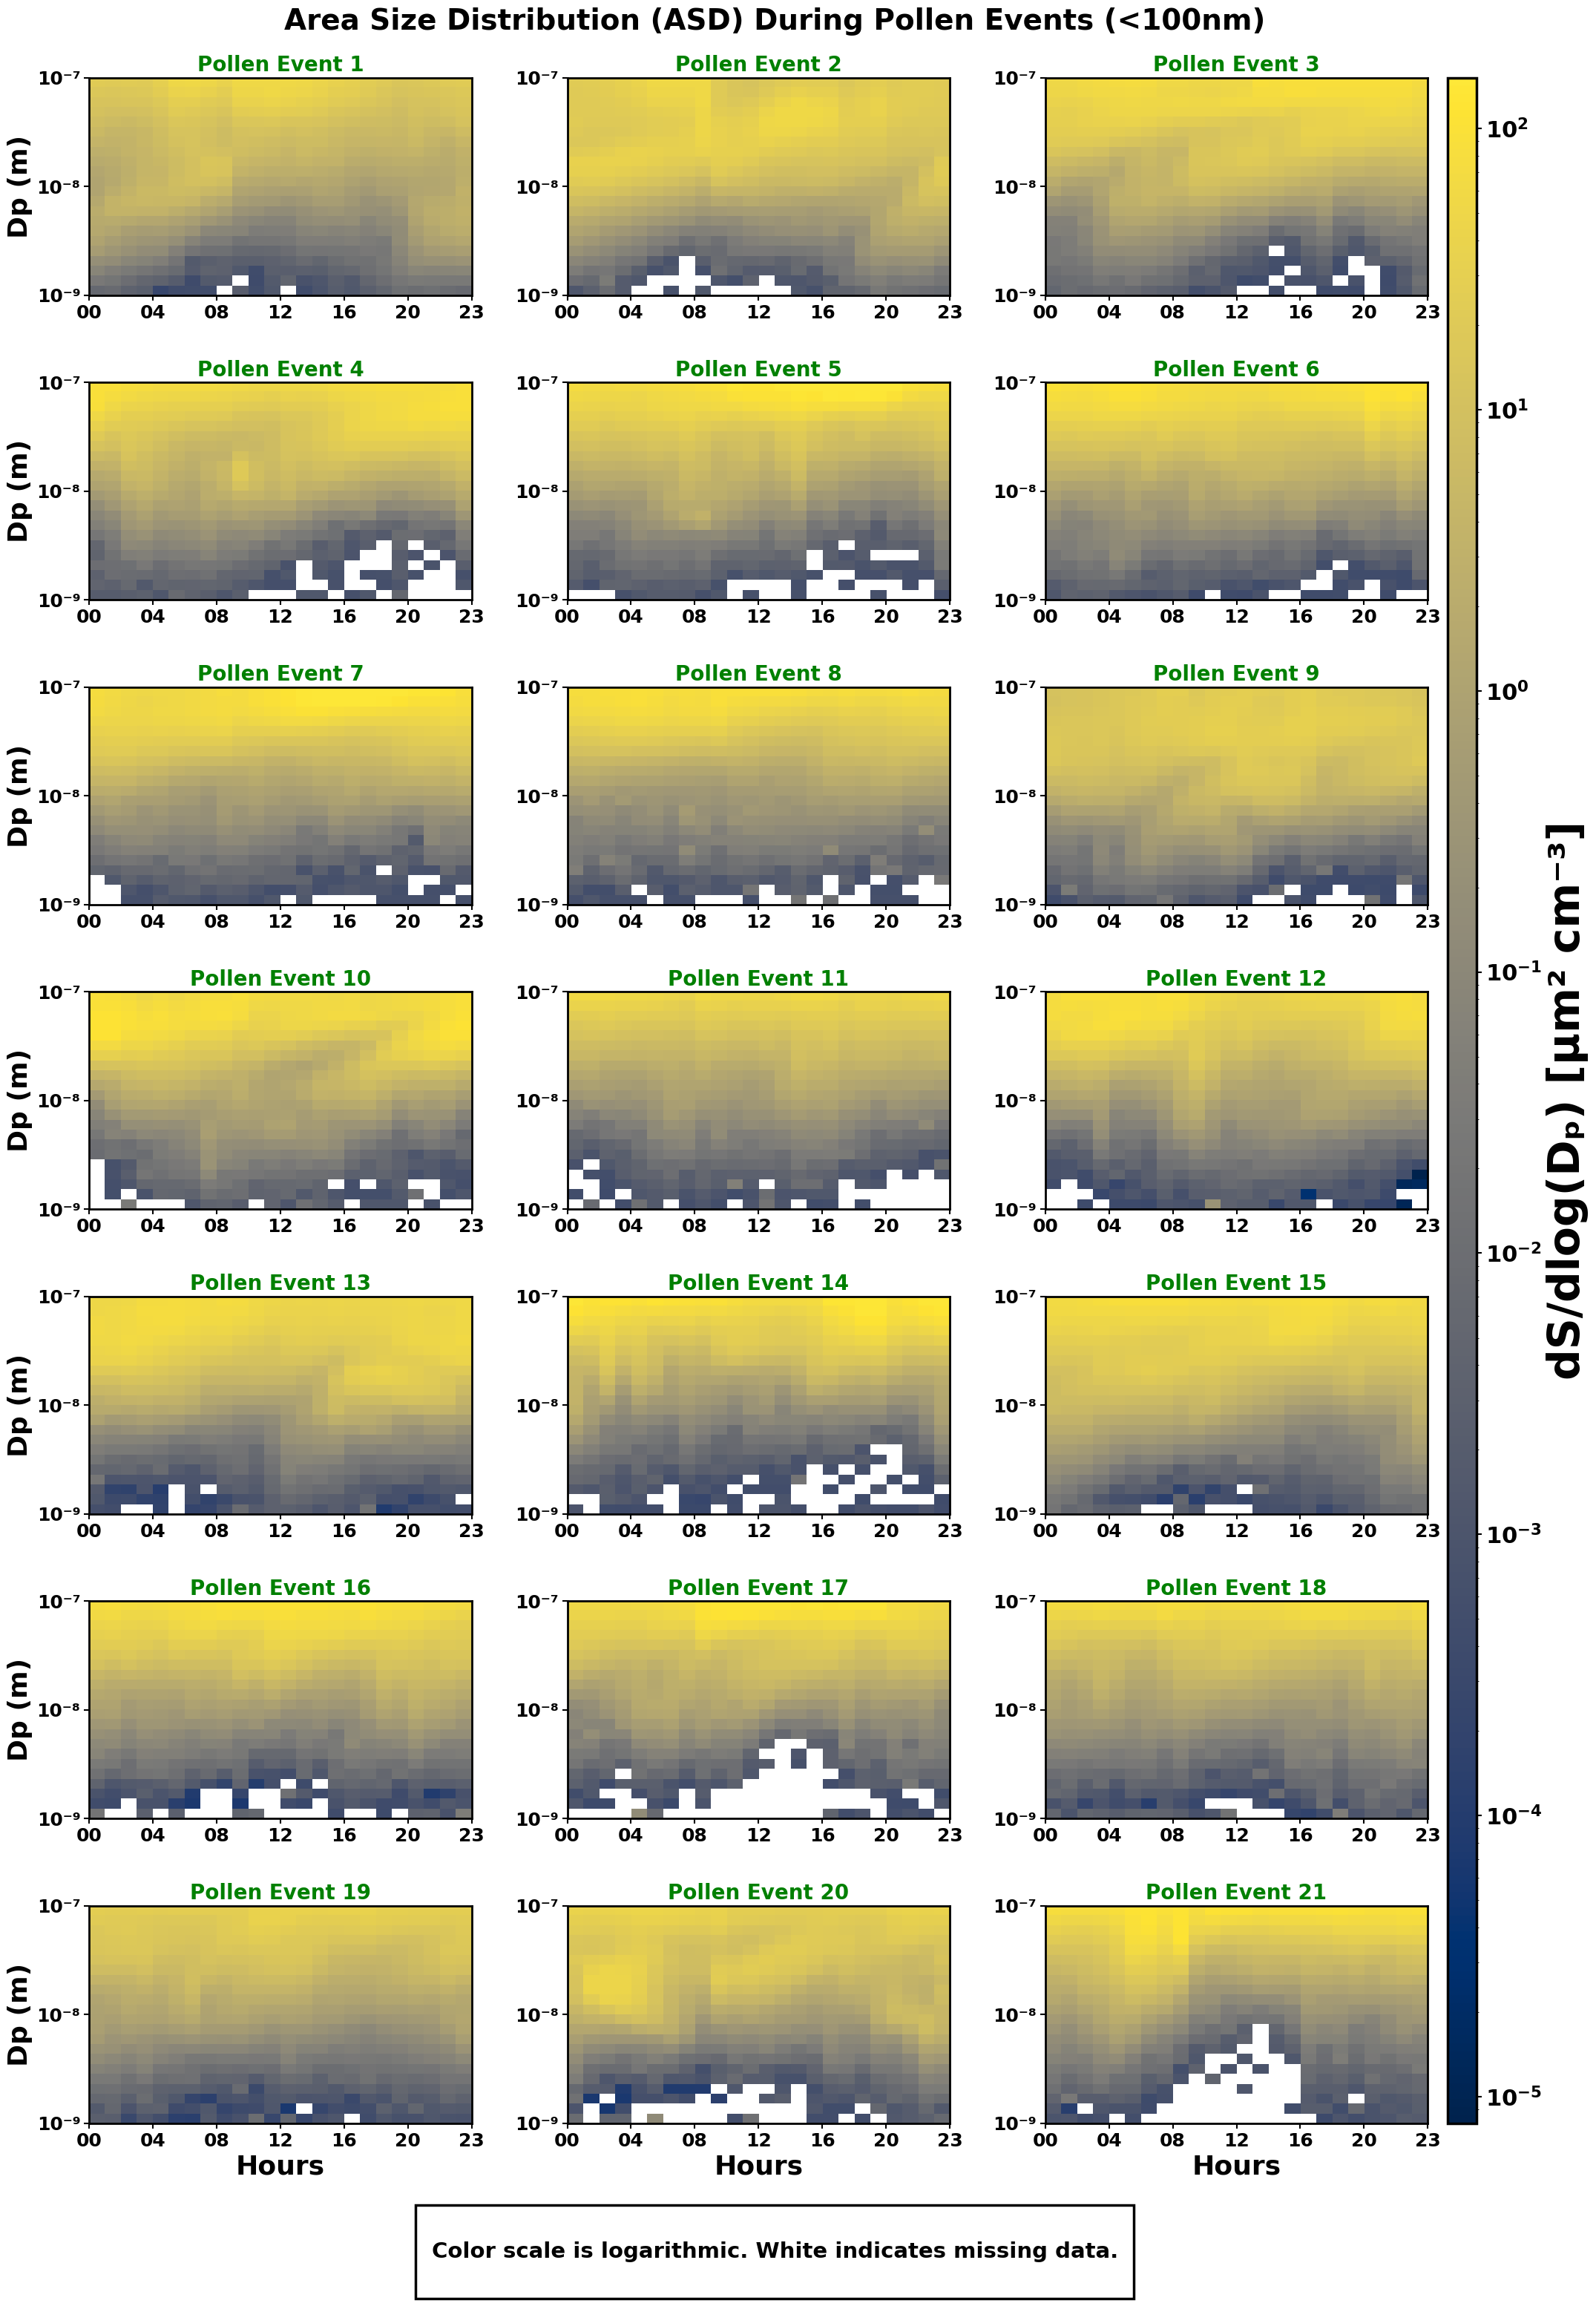


Figure saved successfully!
/Users/touqeergill/Desktop/ASD_All_Pollen_Events.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.patches import Rectangle

# ============================================================
# === FONT SETTINGS ==========================================
# ============================================================

plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.weight"] = "bold"

# ============================================================
# === FOLDER =================================================
# ============================================================

folder_path = "/Users/touqeergill/Desktop/DMPS_APS_Pollen_Days"

# ============================================================
# === NATURAL SORTING ========================================
# ============================================================

def natural_sort_key(s):

    return [

        int(text) if text.isdigit() else text.lower()

        for text in re.split(r'(\d+)', s)

    ]

# ============================================================
# === READ ALL EXCEL FILES ===================================
# ============================================================

excel_files = sorted(

    [

        f

        for f in os.listdir(folder_path)

        if f.endswith(".xlsx")

    ],

    key=natural_sort_key

)

print(f"Total pollen events found: {len(excel_files)}")

# ============================================================
# === PROCESS FUNCTION (ASD) ================================
# ============================================================

def process_event(file_path):

    df = pd.read_excel(

        file_path,

        index_col="datetime",

        parse_dates=True

    )

    # ========================================================
    # === KEEP ONLY Dp < 100 nm ==============================
    # ========================================================

    valid_cols = []

    for c in df.columns:

        try:

            if float(c) < 1e-7:

                valid_cols.append(c)

        except:

            continue

    df = df[valid_cols]

    if df.empty:

        raise ValueError(

            f"No bins below 100 nm in {file_path}"

        )

    # ========================================================
    # === PARTICLE DIAMETER ==================================
    # ========================================================

    Dp_m = df.columns.astype(float)

    Dp_um = Dp_m * 1e6

    # ========================================================
    # === AREA CONVERSION ====================================
    # ========================================================

    factor = np.pi * (Dp_um ** 2)

    df = df.multiply(

        factor,

        axis=1

    )

    # ========================================================
    # === HOURLY MEAN ========================================
    # ========================================================

    df_hourly = df.resample("H").mean()

    diurnal = (

        df_hourly

        .groupby(df_hourly.index.time)

        .mean()

    )

    # ========================================================
    # === MISSING VALUES =====================================
    # ========================================================

    min_positive = df[df > 0].min().min()

    diurnal = diurnal.fillna(min_positive)

    # ========================================================
    # === CLIP EXTREME VALUES ================================
    # ========================================================

    upper_99 = np.nanpercentile(

        diurnal.values,

        99

    )

    diurnal = diurnal.clip(

        upper=min(

            upper_99,

            diurnal.values.max()

        )

    )

    # ========================================================
    # === COMPLETE 24-HOUR AXIS ==============================
    # ========================================================

    time_axis = pd.date_range(

        "00:00",

        "23:00",

        freq="H"

    ).time

    diurnal = (

        diurnal

        .reindex(time_axis)

        .fillna(min_positive)

    )

    # ========================================================
    # === LOG TICKS ==========================================
    # ========================================================

    min_log = np.floor(np.log10(Dp_m.min()))

    max_log = np.ceil(np.log10(Dp_m.max()))

    ticks = np.logspace(

        min_log,

        max_log,

        int(max_log - min_log) + 1

    )

    return (

        diurnal,

        min_positive,

        upper_99,

        ticks,

        min_log,

        max_log

    )

# ============================================================
# === PROCESS ALL EVENTS =====================================
# ============================================================

datasets = {}

for file_name in excel_files:

    datasets[file_name] = process_event(

        os.path.join(

            folder_path,

            file_name

        )

    )

print("All pollen ASD events processed successfully.")

# ============================================================
# === GLOBAL COLOR SCALE =====================================
# ============================================================

asd_vmin = max(

    min(

        datasets[file][1]

        for file in excel_files

    ),

    1e-9

)

asd_vmax = max(

    datasets[file][2]

    for file in excel_files

)

print(f"Global minimum = {asd_vmin:.3e}")
print(f"Global maximum = {asd_vmax:.3e}")

# ============================================================
# === FIGURE LAYOUT ==========================================
# ============================================================

n_files = len(excel_files)

n_cols = 3

n_rows = int(np.ceil(n_files / n_cols))

fig, axes = plt.subplots(

    n_rows,

    n_cols,

    figsize=(22, n_rows * 4.5)

)

axes = axes.flatten()

# ============================================================
# === PLOT FUNCTION ==========================================
# ============================================================

def make_plot(

    ax,

    data,

    title,

    vmin,

    vmax,

    cmap_style="cividis"

):

    diurnal = data[0]

    ticks = data[3]

    min_log = data[4]

    max_log = data[5]

    extent = [

        0,

        len(diurnal),

        min_log,

        max_log

    ]

    im = ax.imshow(

        diurnal.values.T,

        aspect="auto",

        interpolation="none",

        cmap=cmap_style,

        origin="lower",

        extent=extent,

        norm=LogNorm(

            vmin=vmin,

            vmax=vmax

        )

    )

    # ========================================================
    # === TITLE ==============================================
    # ========================================================

    ax.set_title(

        title,

        fontsize=20,

        fontweight="bold",

        color="green"

    )

    # ========================================================
    # === Y AXIS =============================================
    # ========================================================

    ax.set_yticks(np.log10(ticks))

    labels = [

        f"10{str(int(np.log10(t))).translate(str.maketrans('0123456789-', '⁰¹²³⁴⁵⁶⁷⁸⁹⁻'))}"

        for t in ticks

    ]

    ax.set_yticks(

        np.log10(ticks),

        labels=labels

    )

    for tick in ax.get_yticklabels():

        tick.set_fontsize(18)

        tick.set_fontweight("bold")

    # Only first column gets Y-axis label

    if (np.where(axes == ax)[0][0] % n_cols) == 0:

        ax.set_ylabel(

            "Dp (m)",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_ylabel("")

    ax.tick_params(

        axis="y",

        labelsize=18,

        width=1.5,

        length=5

    )

    # ========================================================
    # === X AXIS =============================================
    # ========================================================

    ax.set_xticks(

        np.linspace(

            0,

            len(diurnal),

            7

        )

    )

    ax.set_xticklabels(

        [

            "00",

            "04",

            "08",

            "12",

            "16",

            "20",

            "23"

        ],

        fontsize=18,

        fontweight="bold"

    )

    row_index = np.where(axes == ax)[0][0] // n_cols

    if row_index == n_rows - 1:

        ax.set_xlabel(

            "Hours",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_xlabel("")

    ax.tick_params(

        axis="both",

        which="both",

        width=1.5,

        length=5

    )

    for spine in ax.spines.values():

        spine.set_linewidth(2)

    return im
# ============================================================
# === PLOT ALL POLLEN EVENTS ================================
# ============================================================

letters = list("abcdefghijklmnopqrstuvwxyz")

for i, file_name in enumerate(excel_files):

    data = datasets[file_name]

    title = f"Pollen Event {i+1}"

    im = make_plot(

        axes[i],

        data,

        title,

        asd_vmin,

        asd_vmax,

        cmap_style="cividis"

    )

# ============================================================
# === REMOVE UNUSED AXES =====================================
# ============================================================

for j in range(len(excel_files), len(axes)):

    fig.delaxes(axes[j])

# ============================================================
# === MAIN TITLE =============================================
# ============================================================

fig.suptitle(

    "Area Size Distribution (ASD) During Pollen Events (<100nm)",

    fontsize=28,

    fontweight="bold",

    y=0.995

)

# ============================================================
# === SUBPLOT SPACING ========================================
# ============================================================

fig.subplots_adjust(

    left=0.08,

    right=0.90,

    top=0.965,

    bottom=0.09,

    hspace=0.40,

    wspace=0.25

)

# ============================================================
# === MAKE ALL TICK LABELS BOLD ==============================
# ============================================================

for ax in axes[:len(excel_files)]:

    for tick in ax.get_xticklabels():

        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():

        tick.set_fontweight("bold")
        
        
# ============================================================
# === FULL HEIGHT COLORBAR ===================================
# ============================================================

# Top-right subplot
top_pos = axes[2].get_position()

# Bottom-right subplot
bottom_pos = axes[min(len(excel_files)-1, len(axes)-1)].get_position()

# Colorbar spans the full figure height
cbar_ax = fig.add_axes([

    top_pos.x1 + 0.012,

    bottom_pos.y0,

    0.018,

    top_pos.y1 - bottom_pos.y0

])

cbar = fig.colorbar(

    im,

    cax=cbar_ax

)

cbar.outline.set_linewidth(2.5)

cbar.formatter = LogFormatterMathtext()

cbar.update_ticks()

cbar.ax.tick_params(

    labelsize=22,

    width=1.5,

    length=5

)

for tick in cbar.ax.get_yticklabels():

    tick.set_fontweight("bold")

cbar.set_label(

    "dS/dlog(Dₚ) [µm² cm⁻³]",

    fontsize=42,

    fontweight="bold"

)

# ============================================================
# === FOOTNOTE ===============================================
# ============================================================

rect = Rectangle(

    (

        0.28,

        0.015

    ),

    0.44,

    0.04,

    transform=fig.transFigure,

    facecolor="white",

    edgecolor="black",

    linewidth=2.5

)

fig.add_artist(rect)

fig.text(

    0.50,

    0.035,

    "Color scale is logarithmic. White indicates missing data.",

    ha="center",

    va="center",

    fontsize=21,

    fontweight="bold"

)

# ============================================================
# === SAVE FIGURE ============================================
# ============================================================

output_path = (

    "/Users/touqeergill/Desktop/ASD_All_Pollen_Events.png"

)

plt.savefig(

    output_path,

    dpi=300,

    bbox_inches="tight",

    pad_inches=0.20

)

plt.show()

print()

print("=" * 60)

print("Figure saved successfully!")

print(output_path)

print("=" * 60)

Total dust events found: 15
All dust ASD events processed successfully.
Global minimum = 1.276e-04
Global maximum = 2.531e+02


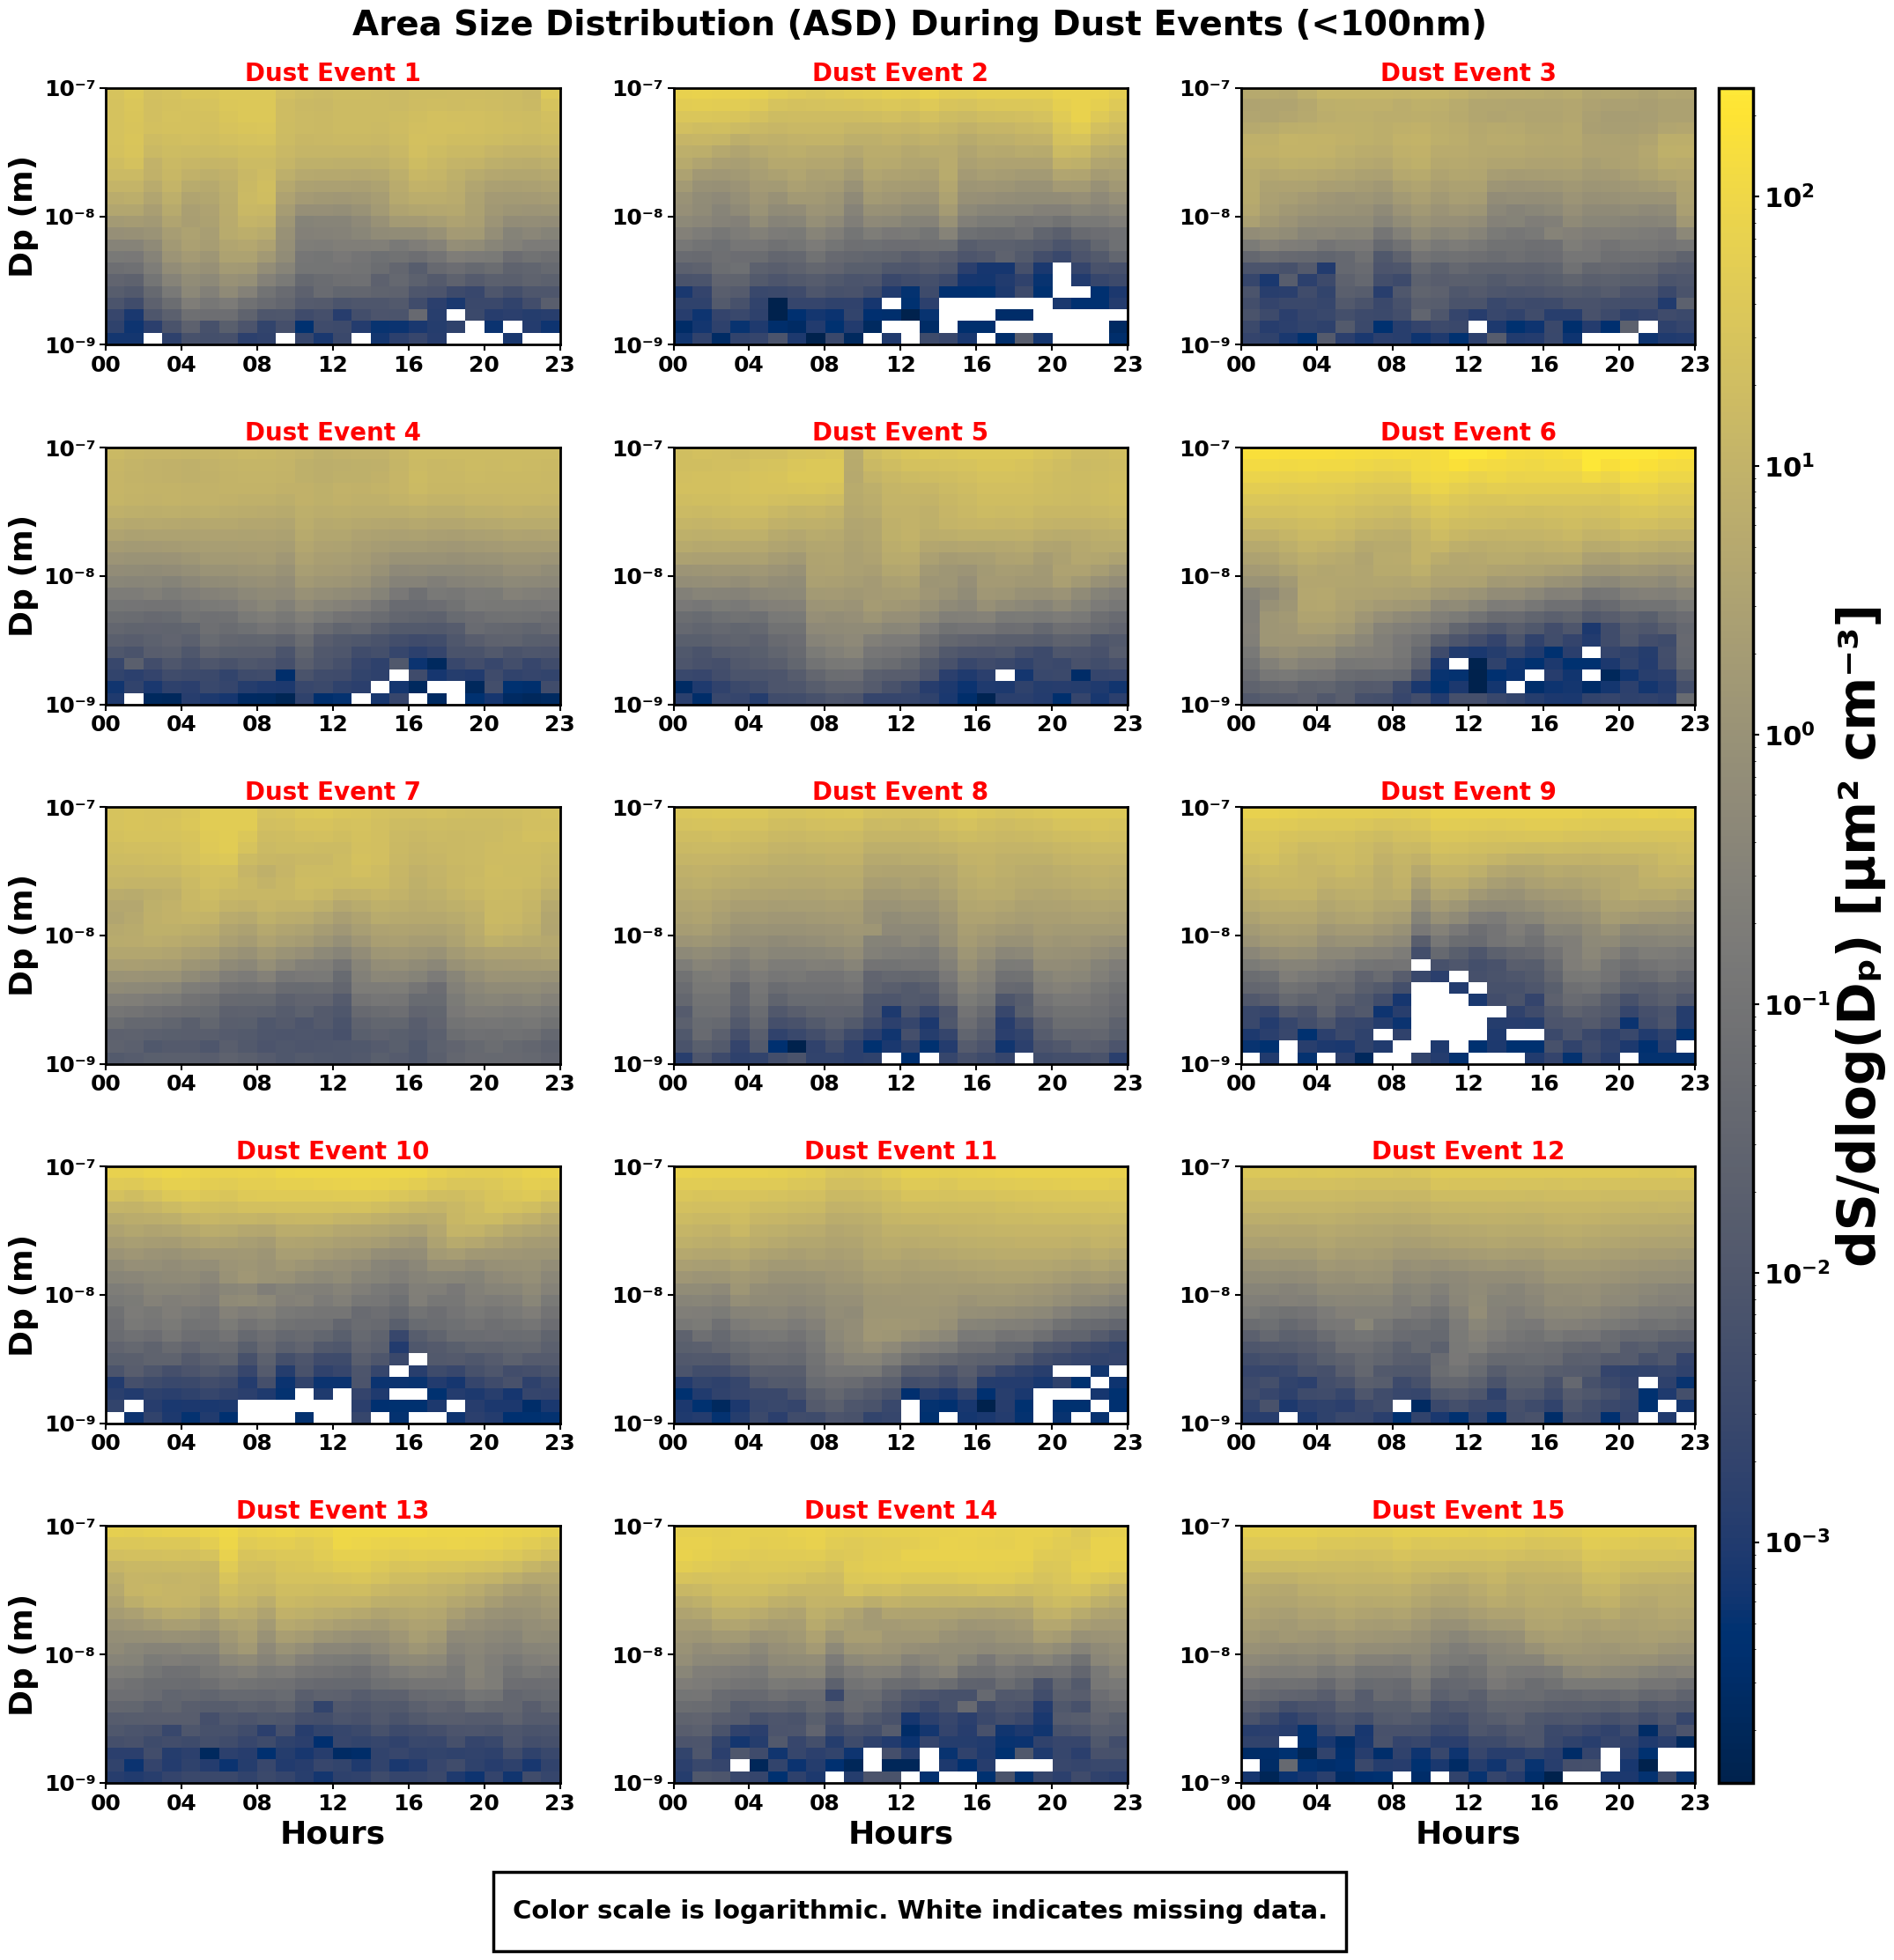


Figure saved successfully!
/Users/touqeergill/Desktop/ASD_All_Dust_Events.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.patches import Rectangle

# ============================================================
# === FONT SETTINGS ==========================================
# ============================================================

plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.weight"] = "bold"

# ============================================================
# === FOLDER =================================================
# ============================================================

folder_path = "/Users/touqeergill/Desktop/DMPS_APS_Dust_Days"

# ============================================================
# === NATURAL SORTING ========================================
# ============================================================

def natural_sort_key(s):

    return [

        int(text) if text.isdigit() else text.lower()

        for text in re.split(r'(\d+)', s)

    ]

# ============================================================
# === READ ALL EXCEL FILES ===================================
# ============================================================

excel_files = sorted(

    [

        f

        for f in os.listdir(folder_path)

        if f.endswith(".xlsx")

    ],

    key=natural_sort_key

)

print(f"Total dust events found: {len(excel_files)}")

# ============================================================
# === PROCESS FUNCTION (ASD) ================================
# ============================================================

def process_event(file_path):

    df = pd.read_excel(

        file_path,

        index_col="datetime",

        parse_dates=True

    )

    # ========================================================
    # === KEEP ONLY Dp < 100 nm ==============================
    # ========================================================

    valid_cols = []

    for c in df.columns:

        try:

            if float(c) < 1e-7:

                valid_cols.append(c)

        except:

            continue

    df = df[valid_cols]

    if df.empty:

        raise ValueError(

            f"No bins below 100 nm in {file_path}"

        )

    # ========================================================
    # === PARTICLE DIAMETER ==================================
    # ========================================================

    Dp_m = df.columns.astype(float)

    Dp_um = Dp_m * 1e6

    # ========================================================
    # === AREA CONVERSION ====================================
    # ========================================================

    factor = np.pi * (Dp_um ** 2)

    df = df.multiply(

        factor,

        axis=1

    )

    # ========================================================
    # === HOURLY MEAN ========================================
    # ========================================================

    df_hourly = df.resample("H").mean()

    diurnal = (

        df_hourly

        .groupby(df_hourly.index.time)

        .mean()

    )

    # ========================================================
    # === MISSING VALUES =====================================
    # ========================================================

    min_positive = df[df > 0].min().min()

    diurnal = diurnal.fillna(min_positive)

    # ========================================================
    # === CLIP EXTREME VALUES ================================
    # ========================================================

    upper_99 = np.nanpercentile(

        diurnal.values,

        99

    )

    diurnal = diurnal.clip(

        upper=min(

            upper_99,

            diurnal.values.max()

        )

    )

    # ========================================================
    # === COMPLETE 24-HOUR AXIS ==============================
    # ========================================================

    time_axis = pd.date_range(

        "00:00",

        "23:00",

        freq="H"

    ).time

    diurnal = (

        diurnal

        .reindex(time_axis)

        .fillna(min_positive)

    )

    # ========================================================
    # === LOG TICKS ==========================================
    # ========================================================

    min_log = np.floor(np.log10(Dp_m.min()))

    max_log = np.ceil(np.log10(Dp_m.max()))

    ticks = np.logspace(

        min_log,

        max_log,

        int(max_log - min_log) + 1

    )

    return (

        diurnal,

        min_positive,

        upper_99,

        ticks,

        min_log,

        max_log

    )

# ============================================================
# === PROCESS ALL EVENTS =====================================
# ============================================================

datasets = {}

for file_name in excel_files:

    datasets[file_name] = process_event(

        os.path.join(

            folder_path,

            file_name

        )

    )

print("All dust ASD events processed successfully.")
# ============================================================
# === GLOBAL COLOR SCALE =====================================
# ============================================================

asd_vmin = max(

    min(

        datasets[file][1]

        for file in excel_files

    ),

    1e-9

)

asd_vmax = max(

    datasets[file][2]

    for file in excel_files

)

print(f"Global minimum = {asd_vmin:.3e}")
print(f"Global maximum = {asd_vmax:.3e}")

# ============================================================
# === FIGURE LAYOUT ==========================================
# ============================================================

n_files = len(excel_files)

n_cols = 3

n_rows = int(np.ceil(n_files / n_cols))

fig, axes = plt.subplots(

    n_rows,

    n_cols,

    figsize=(22, n_rows * 4.5)

)

axes = axes.flatten()

# ============================================================
# === PLOT FUNCTION ==========================================
# ============================================================

def make_plot(

    ax,

    data,

    title,

    vmin,

    vmax,

    cmap_style="cividis"

):

    diurnal = data[0]

    ticks = data[3]

    min_log = data[4]

    max_log = data[5]

    extent = [

        0,

        len(diurnal),

        min_log,

        max_log

    ]

    im = ax.imshow(

        diurnal.values.T,

        aspect="auto",

        interpolation="none",

        cmap=cmap_style,

        origin="lower",

        extent=extent,

        norm=LogNorm(

            vmin=vmin,

            vmax=vmax

        )

    )

    # ========================================================
    # === TITLE ==============================================
    # ========================================================

    ax.set_title(

        title,

        fontsize=20,

        fontweight="bold",

        color="red"

    )

    # ========================================================
    # === Y AXIS =============================================
    # ========================================================

    ax.set_yticks(np.log10(ticks))

    labels = [

        f"10{str(int(np.log10(t))).translate(str.maketrans('0123456789-', '⁰¹²³⁴⁵⁶⁷⁸⁹⁻'))}"

        for t in ticks

    ]

    ax.set_yticks(

        np.log10(ticks),

        labels=labels

    )

    for tick in ax.get_yticklabels():

        tick.set_fontsize(18)

        tick.set_fontweight("bold")

    # Only first column gets Y-axis label

    if (np.where(axes == ax)[0][0] % n_cols) == 0:

        ax.set_ylabel(

            "Dp (m)",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_ylabel("")

    ax.tick_params(

        axis="y",

        labelsize=18,

        width=1.5,

        length=5

    )

    # ========================================================
    # === X AXIS =============================================
    # ========================================================

    ax.set_xticks(

        np.linspace(

            0,

            len(diurnal),

            7

        )

    )

    ax.set_xticklabels(

        [

            "00",

            "04",

            "08",

            "12",

            "16",

            "20",

            "23"

        ],

        fontsize=18,

        fontweight="bold"

    )

    row_index = np.where(axes == ax)[0][0] // n_cols

    if row_index == n_rows - 1:

        ax.set_xlabel(

            "Hours",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_xlabel("")

    ax.tick_params(

        axis="both",

        which="both",

        width=1.5,

        length=5

    )

    for spine in ax.spines.values():

        spine.set_linewidth(2)

    return im
# ============================================================
# === PLOT ALL DUST EVENTS ===================================
# ============================================================

letters = list("abcdefghijklmnopqrstuvwxyz")

for i, file_name in enumerate(excel_files):

    data = datasets[file_name]

    title = f"Dust Event {i+1}"

    im = make_plot(

        axes[i],

        data,

        title,

        asd_vmin,

        asd_vmax,

        cmap_style="cividis"

    )

# ============================================================
# === REMOVE UNUSED AXES =====================================
# ============================================================

for j in range(len(excel_files), len(axes)):

    fig.delaxes(axes[j])

# ============================================================
# === MAIN TITLE =============================================
# ============================================================

fig.suptitle(

    "Area Size Distribution (ASD) During Dust Events (<100nm)",

    fontsize=28,

    fontweight="bold",

    y=0.995

)

# ============================================================
# === SUBPLOT SPACING ========================================
# ============================================================

fig.subplots_adjust(

    left=0.08,

    right=0.90,

    top=0.955,

    bottom=0.10,

    hspace=0.40,

    wspace=0.25

)

# ============================================================
# === MAKE ALL TICK LABELS BOLD ==============================
# ============================================================

for ax in axes[:len(excel_files)]:

    for tick in ax.get_xticklabels():

        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():

        tick.set_fontweight("bold")
        # ============================================================
# === FULL HEIGHT COLORBAR ===================================
# ============================================================

# Top-right subplot
top_pos = axes[2].get_position()

# Bottom-right subplot
bottom_pos = axes[min(len(excel_files)-1, len(axes)-1)].get_position()

# Colorbar spans the full figure height
cbar_ax = fig.add_axes([

    top_pos.x1 + 0.012,

    bottom_pos.y0,

    0.018,

    top_pos.y1 - bottom_pos.y0

])

cbar = fig.colorbar(

    im,

    cax=cbar_ax

)

cbar.outline.set_linewidth(2.5)

cbar.formatter = LogFormatterMathtext()

cbar.update_ticks()

cbar.ax.tick_params(

    labelsize=22,

    width=1.5,

    length=5

)

for tick in cbar.ax.get_yticklabels():

    tick.set_fontweight("bold")

cbar.set_label(

    "dS/dlog(Dₚ) [µm² cm⁻³]",

    fontsize=42,

    fontweight="bold"

)

# ============================================================
# === FOOTNOTE ===============================================
# ============================================================

rect = Rectangle(

    (

        0.28,

        0.015

    ),

    0.44,

    0.04,

    transform=fig.transFigure,

    facecolor="white",

    edgecolor="black",

    linewidth=2.5

)

fig.add_artist(rect)

fig.text(

    0.50,

    0.035,

    "Color scale is logarithmic. White indicates missing data.",

    ha="center",

    va="center",

    fontsize=21,

    fontweight="bold"

)

# ============================================================
# === SAVE FIGURE ============================================
# ============================================================

output_path = (

    "/Users/touqeergill/Desktop/ASD_All_Dust_Events.png"

)

plt.savefig(

    output_path,

    dpi=300,

    bbox_inches="tight",

    pad_inches=0.20

)

plt.show()

print()

print("=" * 60)

print("Figure saved successfully!")

print(output_path)

print("=" * 60)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.patches import Rectangle

# ============================================================
# === FONT SETTINGS ==========================================
# ============================================================

plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.weight"] = "bold"

# ============================================================
# === FOLDER =================================================
# ============================================================

folder_path = "/Users/touqeergill/Desktop/DMPS_APS_Pollen_Days"

# ============================================================
# === NATURAL SORTING ========================================
# ============================================================

def natural_sort_key(s):

    return [

        int(text) if text.isdigit() else text.lower()

        for text in re.split(r'(\d+)', s)

    ]

# ============================================================
# === READ ALL EXCEL FILES ===================================
# ============================================================

excel_files = sorted(

    [

        f

        for f in os.listdir(folder_path)

        if f.endswith(".xlsx")

    ],

    key=natural_sort_key

)

print(f"Total pollen events found: {len(excel_files)}")

# ============================================================
# === PROCESS FUNCTION (VSD) ================================
# ============================================================

def process_event(file_path):

    df = pd.read_excel(

        file_path,

        index_col="datetime",

        parse_dates=True

    )

    # ========================================================
    # === KEEP ONLY Dp < 100 nm ==============================
    # ========================================================

    valid_cols = []

    for c in df.columns:

        try:

            if float(c) < 1e-7:

                valid_cols.append(c)

        except:

            continue

    df = df[valid_cols]

    if df.empty:

        raise ValueError(

            f"No bins below 100 nm in {file_path}"

        )

    # ========================================================
    # === PARTICLE DIAMETER ==================================
    # ========================================================

    Dp_m = df.columns.astype(float)

    Dp_um = Dp_m * 1e6

    # ========================================================
    # === VOLUME CONVERSION ==================================
    # ========================================================

    factor = (np.pi / 6) * (Dp_um ** 3)

    df = df.multiply(

        factor,

        axis=1

    )

    # ========================================================
    # === HOURLY MEAN ========================================
    # ========================================================

    df_hourly = df.resample("H").mean()

    diurnal = (

        df_hourly

        .groupby(df_hourly.index.time)

        .mean()

    )

    # ========================================================
    # === MISSING VALUES =====================================
    # ========================================================

    min_positive = df[df > 0].min().min()

    diurnal = diurnal.fillna(min_positive)

    # ========================================================
    # === CLIP EXTREME VALUES ================================
    # ========================================================

    upper_99 = np.nanpercentile(

        diurnal.values,

        99

    )

    diurnal = diurnal.clip(

        upper=min(

            upper_99,

            diurnal.values.max()

        )

    )

    # ========================================================
    # === COMPLETE 24-HOUR AXIS ==============================
    # ========================================================

    time_axis = pd.date_range(

        "00:00",

        "23:00",

        freq="H"

    ).time

    diurnal = (

        diurnal

        .reindex(time_axis)

        .fillna(min_positive)

    )

    # ========================================================
    # === LOG TICKS ==========================================
    # ========================================================

    min_log = np.floor(np.log10(Dp_m.min()))

    max_log = np.ceil(np.log10(Dp_m.max()))

    ticks = np.logspace(

        min_log,

        max_log,

        int(max_log - min_log) + 1

    )

    return (

        diurnal,

        min_positive,

        upper_99,

        ticks,

        min_log,

        max_log

    )

# ============================================================
# === PROCESS ALL EVENTS =====================================
# ============================================================

datasets = {}

for file_name in excel_files:

    datasets[file_name] = process_event(

        os.path.join(

            folder_path,

            file_name

        )

    )

print("All pollen VSD events processed successfully.")

# ============================================================
# === GLOBAL COLOR SCALE =====================================
# ============================================================

vsd_vmin = max(

    min(

        datasets[file][1]

        for file in excel_files

    ),

    1e-9

)

vsd_vmax = max(

    datasets[file][2]

    for file in excel_files

)

print(f"Global minimum = {vsd_vmin:.3e}")
print(f"Global maximum = {vsd_vmax:.3e}")

# ============================================================
# === FIGURE LAYOUT ==========================================
# ============================================================

n_files = len(excel_files)

n_cols = 3

n_rows = int(np.ceil(n_files / n_cols))

fig, axes = plt.subplots(

    n_rows,

    n_cols,

    figsize=(22, n_rows * 4.5)

)

axes = axes.flatten()

# ============================================================
# === PLOT FUNCTION ==========================================
# ============================================================

def make_plot(

    ax,

    data,

    title,

    vmin,

    vmax,

    cmap_style="magma"

):

    diurnal = data[0]

    ticks = data[3]

    min_log = data[4]

    max_log = data[5]

    extent = [

        0,

        len(diurnal),

        min_log,

        max_log

    ]

    im = ax.imshow(

        diurnal.values.T,

        aspect="auto",

        interpolation="none",

        cmap=cmap_style,

        origin="lower",

        extent=extent,

        norm=LogNorm(

            vmin=vmin,

            vmax=vmax

        )

    )

    # ========================================================
    # === TITLE ==============================================
    # ========================================================

    ax.set_title(

        title,

        fontsize=20,

        fontweight="bold",

        color="green"

    )

    # ========================================================
    # === Y AXIS =============================================
    # ========================================================

    ax.set_yticks(np.log10(ticks))

    labels = [

        f"10{str(int(np.log10(t))).translate(str.maketrans('0123456789-', '⁰¹²³⁴⁵⁶⁷⁸⁹⁻'))}"

        for t in ticks

    ]

    ax.set_yticks(

        np.log10(ticks),

        labels=labels

    )

    for tick in ax.get_yticklabels():

        tick.set_fontsize(18)

        tick.set_fontweight("bold")

    # ========================================================
    # === Y LABEL ============================================
    # ========================================================

    if (np.where(axes == ax)[0][0] % n_cols) == 0:

        ax.set_ylabel(

            "Dp (m)",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_ylabel("")

    ax.tick_params(

        axis="y",

        labelsize=18,

        width=1.5,

        length=5

    )

    # ========================================================
    # === X AXIS =============================================
    # ========================================================

    ax.set_xticks(

        np.linspace(

            0,

            len(diurnal),

            7

        )

    )

    ax.set_xticklabels(

        [

            "00",

            "04",

            "08",

            "12",

            "16",

            "20",

            "23"

        ],

        fontsize=18,

        fontweight="bold"

    )

    row_index = np.where(axes == ax)[0][0] // n_cols

    if row_index == n_rows - 1:

        ax.set_xlabel(

            "Hours",

            fontsize=26,

            fontweight="bold"

        )

    else:

        ax.set_xlabel("")

    ax.tick_params(

        axis="both",

        which="both",

        width=1.5,

        length=5

    )

    for spine in ax.spines.values():

        spine.set_linewidth(2)

    return im

# ============================================================
# === PLOT ALL POLLEN EVENTS ================================
# ============================================================

letters = list("abcdefghijklmnopqrstuvwxyz")

for i, file_name in enumerate(excel_files):

    data = datasets[file_name]

    title = f"Pollen Event {i+1}"

    im = make_plot(

        axes[i],

        data,

        title,

        vsd_vmin,

        vsd_vmax,

        cmap_style="magma"

    )

# ============================================================
# === REMOVE UNUSED AXES =====================================
# ============================================================

for j in range(len(excel_files), len(axes)):

    fig.delaxes(axes[j])

# ============================================================
# === MAIN TITLE =============================================
# ============================================================

fig.suptitle(

    "Volume Size Distribution (VSD) During Pollen Events",

    fontsize=28,

    fontweight="bold",

    y=0.995

)

# ============================================================
# === SUBPLOT SPACING ========================================
# ============================================================

fig.subplots_adjust(

    left=0.08,

    right=0.90,

    top=0.965,

    bottom=0.09,

    hspace=0.40,

    wspace=0.25

)

# ============================================================
# === MAKE ALL TICK LABELS BOLD ==============================
# ============================================================

for ax in axes[:len(excel_files)]:

    for tick in ax.get_xticklabels():

        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():

        tick.set_fontweight("bold")
                        
# ============================================================
# === FULL HEIGHT COLORBAR ===================================
# ============================================================

# Top-right subplot
top_pos = axes[2].get_position()

# Bottom-right subplot
bottom_pos = axes[min(len(excel_files)-1, len(axes)-1)].get_position()

# Colorbar spans the full figure height
cbar_ax = fig.add_axes([

    top_pos.x1 + 0.012,

    bottom_pos.y0,

    0.018,

    top_pos.y1 - bottom_pos.y0

])

cbar = fig.colorbar(

    im,

    cax=cbar_ax

)

cbar.outline.set_linewidth(2.5)

cbar.formatter = LogFormatterMathtext()

cbar.update_ticks()

cbar.ax.tick_params(

    labelsize=22,

    width=1.5,

    length=5

)

for tick in cbar.ax.get_yticklabels():

    tick.set_fontweight("bold")

cbar.set_label(

    "dV/dlog(Dₚ) [µm³ cm⁻³]",

    fontsize=42,

    fontweight="bold"

)

# ============================================================
# === FOOTNOTE ===============================================
# ============================================================

rect = Rectangle(

    (

        0.28,

        0.015

    ),

    0.44,

    0.04,

    transform=fig.transFigure,

    facecolor="white",

    edgecolor="black",

    linewidth=2.5

)

fig.add_artist(rect)

fig.text(

    0.50,

    0.035,

    "Color scale is logarithmic. White indicates missing data.",

    ha="center",

    va="center",

    fontsize=21,

    fontweight="bold"

)

# ============================================================
# === SAVE FIGURE ============================================
# ============================================================

output_path = (

    "/Users/touqeergill/Desktop/VSD_All_Pollen_Events.png"

)

plt.savefig(

    output_path,

    dpi=300,

    bbox_inches="tight",

    pad_inches=0.20

)

plt.show()

print()

print("=" * 60)

print("Figure saved successfully!")

print(output_path)

print("=" * 60)          